# Вариант 11. Ссылка на папку с дз на яндекс диске https://disk.360.yandex.ru/d/EGXkwJfJPrK9WA

In [29]:
import numpy as np
import pandas as pd
from tabulate import tabulate
pd.set_option('display.max_columns', None)

## Часть 1

### Считывание данных и их чистка

In [11]:
data = pd.read_csv('HW1_var_11.csv', sep = ';')

In [12]:
data.head()

,Номер варианта,ID,INCOME_BASE_TYPE,CREDIT_PURPOSE,INSURANCE_FLAG,DTI,SEX,FULL_AGE_CHILD_NUMBER,DEPENDANT_NUMBER,EDUCATION,EMPL_TYPE,EMPL_SIZE,BANKACCOUNT_FLAG,Period_at_work,age,EMPL_PROPERTY,EMPL_FORM,FAMILY_STATUS,max90days,max60days,max30days,max21days,max14days,avg_num_delay,if_zalog,num_AccountActive180,num_AccountActive90,num_AccountActive60,Active_to_All_prc,numAccountActiveAll,numAccountClosed,sum_of_paym_months,all_credits,Active_not_cc,own_closed,min_MnthAfterLoan,max_MnthAfterLoan,dlq_exist,thirty_in_a_year,sixty_in_a_year,ninety_in_a_year,thirty_vintage,sixty_vintage,ninety_vintage
0,11,1000011,Поступление зарплаты на счет,Другое,0,0.33,женский,0,0,высшее,вспомогательный персонал,>100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,11,1000031,Форма банка (без печати работодателя),Лечение,1,0.49,женский,0,0,среднее-специальное,вспомогательный персонал,>250,0.0,109.0,46.0,Торговля,ЗАО,холост / не замужем,3.0,2.0,2.0,1.0,0.0,0.089109,0.0,0.0,0.0,0.0,0.600000,3.0,2.0,92.0,5.0,2.0,1.0,17.0,43.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,11,1000051,2НДФЛ,Другое,1,0.59,женский,0,0,среднее-специальное,вспомогательный персонал,>250,0.0,47.0,47.0,Торговля,ООО,холост / не замужем,1.0,0.0,0.0,0.0,0.0,0.006369,1.0,0.0,0.0,0.0,0.555556,5.0,4.0,156.0,9.0,3.0,1.0,18.0,89.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,11,1000071,Поступление зарплаты на счет,Покупка автомобиля,1,0.36,мужской,0,0,высшее,специалист,>250,0.0,32.0,27.0,Информационные технологии,ООО,холост / не замужем,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,1.0,7.0,1.0,0.0,1.0,32.0,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,11,1000091,Свободная форма с печатью работодателя,Ремонт,1,0.53,женский,0,0,высшее,специалист,< 50,0.0,27.0,50.0,Производство,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Список признаков и их тип**

| Атрибут | Описание | Тип признака |
|:--------|:---------|:------------:|
| Номер варианта | Номер варианта | - |
| ID | Идентификатор клиента | - |
| INCOME_BASE_TYPE | Подтверждение дохода | категориальный |
| CREDIT_PURPOSE | Цель получения кредита | категориальный |
| INSURANCE_FLAG | Страхование заемщика при получении кредита | категориальный |
| DTI | debt-to-income ratio — отношение долга к доходам | количественный |
| SEX | Пол | категориальный |
| FULL_AGE_CHILD_NUMBER | Кол-во лет ребенку | количественный |
| DEPENDANT_NUMBER | Кол-во иждивенцев | количественный |
| EDUCATION | Образование | категориальный |
| EMPL_TYPE | Должность | категориальный |
| EMPL_SIZE | Зарплата | категориальный |
| BANKACCOUNT_FLAG | Кол-во аккаунтов у клиента. (0 - нет онлайн-кабинета, 1 - есть один онлайн-кабинет, 2 и более - заходил в онлайн-кабинет с другого устройства) | категориальный |
| Period_at_work | Время работы (кол-во дней) | количественный |
| age | Возраст | количественный |
| EMPL_PROPERTY | Сфера бизнеса работодателя | категориальный |
| EMPL_FORM | Организационно-правовая форма | категориальный |
| FAMILY_STATUS | Семейный статус | категориальный |
| max90days | кол-во запросов в бюро кредитных историй за последние 90 дней | количественный |
| max60days | кол-во запросов в бюро кредитных историй за последние 60 дней | количественный |
| max30days | кол-во запросов в бюро кредитных историй за последние 30 дней | количественный |
| max21days | кол-во запросов в бюро кредитных историй за последние 21 дней | количественный |
| max14days | кол-во запросов в бюро кредитных историй за последние 14 дней | количественный |
| avg_num_delay | Среднее кол-во задержки оплаты | количественный |
| if_zalog | Наличие залога (квартира, машина) | категориальный |
| num_AccountActive180 | кол-во активных счетов за последние 180 дней | количественный |
| num_AccountActive90 | кол-во активных счетов за последние 90 дней | количественный |
| num_AccountActive60 | кол-во активных счетов за последние 60 дней | количественный |
| Active_to_All_prc | отношение активных счетов ко всем счетам | количественный |
| numAccountActiveAll | кол-во открытых счетов | количественный |
| numAccountClosed | кол-во закрытых счетов | количественный |
| sum_of_paym_months | сумма платежей за последний месяц (тыс.) | количественный |
| all_credits | Кол-во кредитов | количественный |
| Active_not_cc | Активные кредитные счета, но не кредитная карта | количественный |
| own_closed | Кол-во закрытых кредитов | количественный |
| min_MnthAfterLoan | минимальное кол-во месяцев, которое прошло с момента взятия прошлого кредита, то есть как давно выдали последний кредит клиенту | количественный |
| max_MnthAfterLoan | кол-во месяцев прошедшее с момента выдачи первого кредита | количественный |
| dlq_exist | наличие просрочки на данный момент | категориальный |
| thirty_in_a_year | просрочка больше 30 дней за последний год | категориальный |
| sixty_in_a_year | просрочка больше 60 дней за последний год | категориальный |
| ninety_in_a_year | просрочка больше 90 дней за последний год | категориальный |
| thirty_vintage | просрочка больше 30 дней, когда-либо | категориальный |
| sixty_vintage | просрочка больше 60 дней, когда-либо | категориальный |
| ninety_vintage | просрочка больше 90 дней, когда-либо | категориальный |

**Создадим сразу два списка с каждым типом переменных, чтобы удобнее было вычислять корреляции**

In [65]:
categorical_features = [
    'INCOME_BASE_TYPE',        # Подтверждение дохода
    'CREDIT_PURPOSE',          # Цель получения кредита
    'INSURANCE_FLAG',          # Страхование заемщика при получении кредита
    'SEX',                     # Пол
    'EDUCATION',               # Образование
    'EMPL_TYPE',               # Должность
    'EMPL_SIZE',               # Зарплата
    'BANKACCOUNT_FLAG',        # Кол-во аккаунтов у клиента
    'EMPL_PROPERTY',           # Сфера бизнеса работодателя
    'EMPL_FORM',               # Организационно-правовая форма
    'FAMILY_STATUS',           # Семейный статус
    'if_zalog',                # Наличие залога (квартира, машина)
    'dlq_exist',               # наличие просрочки на данный момент
    'thirty_in_a_year',        # просрочка больше 30 дней за последний год
    'sixty_in_a_year',         # просрочка больше 60 дней за последний год
    'ninety_in_a_year',        # просрочка больше 90 дней за последний год
    'thirty_vintage',          # просрочка больше 30 дней, когда-либо
    'sixty_vintage',           # просрочка больше 60 дней, когда-либо
    'ninety_vintage'           # просрочка больше 90 дней, когда-либо
]
numerical_features = [
    'DTI',                     # debt-to-income ratio
    'FULL_AGE_CHILD_NUMBER',   # Кол-во лет ребенку
    'DEPENDANT_NUMBER',        # Кол-во иждивенцев
    'Period_at_work',          # Время работы (кол-во дней)
    'age',                     # Возраст
    'max90days',               # запросы в БКИ за 90 дней
    'max60days',               # запросы в БКИ за 60 дней
    'max30days',               # запросы в БКИ за 30 дней
    'max21days',               # запросы в БКИ за 21 дней
    'max14days',               # запросы в БКИ за 14 дней
    'avg_num_delay',           # Среднее кол-во задержки оплаты
    'num_AccountActive180',    # активные счета за 180 дней
    'num_AccountActive90',     # активные счета за 90 дней
    'num_AccountActive60',     # активные счета за 60 дней
    'Active_to_All_prc',       # отношение активных счетов ко всем
    'numAccountActiveAll',     # кол-во открытых счетов
    'numAccountClosed',        # кол-во закрытых счетов
    'sum_of_paym_months',      # сумма платежей за последний месяц
    'all_credits',             # Кол-во кредитов
    'Active_not_cc',           # Активные кредитные счета (не карты)
    'own_closed',              # Кол-во закрытых кредитов
    'min_MnthAfterLoan',       # минимальное кол-во месяцев с последнего кредита
    'max_MnthAfterLoan'        # кол-во месяцев с первого кредита
]

In [32]:
data = data.drop(columns = 'Номер варианта')

In [33]:
#размерность датасета
print(f'Кол-во строк = {data.shape[0]}, кол-во столбцов = {data.shape[1]}')

Кол-во строк = 10242, кол-во столбцов = 43


data

In [34]:
#Список столбцов
print('\n'.join(data.columns))

ID
INCOME_BASE_TYPE
CREDIT_PURPOSE
INSURANCE_FLAG
DTI
SEX
FULL_AGE_CHILD_NUMBER
DEPENDANT_NUMBER
EDUCATION
EMPL_TYPE
EMPL_SIZE
BANKACCOUNT_FLAG
Period_at_work
age
EMPL_PROPERTY
EMPL_FORM
FAMILY_STATUS
max90days
max60days
max30days
max21days
max14days
avg_num_delay
if_zalog
num_AccountActive180
num_AccountActive90
num_AccountActive60
Active_to_All_prc
numAccountActiveAll
numAccountClosed
sum_of_paym_months
all_credits
Active_not_cc
own_closed
min_MnthAfterLoan
max_MnthAfterLoan
dlq_exist
thirty_in_a_year
sixty_in_a_year
ninety_in_a_year
thirty_vintage
sixty_vintage
ninety_vintage


In [35]:
def columnValues(data):
    row = [data.nunique(), (data == 0).sum(axis=0), data.isna().sum(), round(data.isna().sum() / len(data) * 100, 1), data.dtypes]
    return row

d = []
for column in data:
    d.append([column] + columnValues(data[column]))

print(tabulate(d, headers=['Column', 'Count Unique', 'Count Zeros', 'Count NaNs','% of NaNs', 'data type'], tablefmt='orgtbl'))

| Column                |   Count Unique |   Count Zeros |   Count NaNs |   % of NaNs | data type   |
|-----------------------+----------------+---------------+--------------+-------------+-------------|
| ID                    |          10242 |             0 |            0 |         0   | int64       |
| INCOME_BASE_TYPE      |              4 |             0 |           61 |         0.6 | object      |
| CREDIT_PURPOSE        |             10 |             0 |            0 |         0   | object      |
| INSURANCE_FLAG        |              2 |          3975 |            0 |         0   | int64       |
| DTI                   |             60 |             2 |          122 |         1.2 | float64     |
| SEX                   |              2 |             0 |            0 |         0   | object      |
| FULL_AGE_CHILD_NUMBER |              6 |          6073 |            0 |         0   | int64       |
| DEPENDANT_NUMBER      |              4 |         10214 |            0 |         

In [80]:
#Заметим, что пропуски 63,3% - это одни и те же строки
((data['sixty_in_a_year'].isna())&(data['thirty_vintage'].isna())&(data['ninety_vintage'].isna())).sum()

6479

In [81]:
#В это же множество входят пропуски и по столбцам с долей 60,8%
((data['max14days'].isna())&(data['thirty_vintage'].isna())&(data['ninety_vintage'].isna())).sum()

6225

In [82]:
#И в это же множество входят пропуски и по столбцам с долей 22,5% 
((data['max14days'].isna())&(data['Period_at_work'].isna())&(data['ninety_vintage'].isna())).sum()

2304

In [83]:
10242 - 6479

3763

In [1108]:
#Удалим пропуски. Скорее всего клиенты с пропусками - это клиенты без кредитной истории, новые клиенты 
data_copy = data.copy().dropna(subset = ['ninety_vintage'])

In [1109]:
#После удаления
def columnValues(data_copy):
    row = [data_copy.nunique(), (data_copy == 0).sum(axis=0), data_copy.isna().sum(), round(data_copy.isna().sum() / len(data_copy) * 100, 1), data_copy.dtypes]
    return row

d = []
for column in data:
    d.append([column] + columnValues(data_copy[column]))

print(tabulate(d, headers=['Column', 'Count Unique', 'Count Zeros', 'Count NaNs','% of NaNs', 'data type'], tablefmt='orgtbl'))

| Column                |   Count Unique |   Count Zeros |   Count NaNs |   % of NaNs | data type   |
|-----------------------+----------------+---------------+--------------+-------------+-------------|
| ID                    |           3763 |             0 |            0 |         0   | int64       |
| INCOME_BASE_TYPE      |              4 |             0 |            0 |         0   | object      |
| CREDIT_PURPOSE        |             10 |             0 |            0 |         0   | object      |
| INSURANCE_FLAG        |              2 |          1443 |            0 |         0   | int64       |
| DTI                   |             57 |             1 |            1 |         0   | float64     |
| SEX                   |              2 |             0 |            0 |         0   | object      |
| FULL_AGE_CHILD_NUMBER |              5 |          2254 |            0 |         0   | int64       |
| DEPENDANT_NUMBER      |              3 |          3755 |            0 |         

In [1110]:
#удалим также пропуски по столбцам DTI и avg_num_delay (их всего 15 строк)
data_copy = data_copy.dropna()

In [1111]:
def columnValues(data_copy):
    row = [data_copy.nunique(), (data_copy == 0).sum(axis=0), data_copy.isna().sum(), round(data_copy.isna().sum() / len(data_copy) * 100, 1), data_copy.dtypes]
    return row

d = []
for column in data:
    d.append([column] + columnValues(data_copy[column]))

print(tabulate(d, headers=['Column', 'Count Unique', 'Count Zeros', 'Count NaNs','% of NaNs', 'data type'], tablefmt='orgtbl'))

| Column                |   Count Unique |   Count Zeros |   Count NaNs |   % of NaNs | data type   |
|-----------------------+----------------+---------------+--------------+-------------+-------------|
| ID                    |           3745 |             0 |            0 |           0 | int64       |
| INCOME_BASE_TYPE      |              4 |             0 |            0 |           0 | object      |
| CREDIT_PURPOSE        |             10 |             0 |            0 |           0 | object      |
| INSURANCE_FLAG        |              2 |          1433 |            0 |           0 | int64       |
| DTI                   |             57 |             1 |            0 |           0 | float64     |
| SEX                   |              2 |             0 |            0 |           0 | object      |
| FULL_AGE_CHILD_NUMBER |              5 |          2243 |            0 |           0 | int64       |
| DEPENDANT_NUMBER      |              3 |          3737 |            0 |         

In [1112]:
#размерность датасета
print(f'Кол-во строк = {data_copy.shape[0]}, кол-во столбцов = {data_copy.shape[1]}')

Кол-во строк = 3745, кол-во столбцов = 43


In [1113]:
data_copy.describe()

,ID,INSURANCE_FLAG,DTI,FULL_AGE_CHILD_NUMBER,DEPENDANT_NUMBER,BANKACCOUNT_FLAG,Period_at_work,age,max90days,max60days,max30days,max21days,max14days,avg_num_delay,if_zalog,num_AccountActive180,num_AccountActive90,num_AccountActive60,Active_to_All_prc,numAccountActiveAll,numAccountClosed,sum_of_paym_months,all_credits,Active_not_cc,own_closed,min_MnthAfterLoan,max_MnthAfterLoan,dlq_exist,thirty_in_a_year,sixty_in_a_year,ninety_in_a_year,thirty_vintage,sixty_vintage,ninety_vintage
count,3.745000e+03,3745.000000,3745.000000,3745.000000,3745.000000,3745.000000,3745.000000,3745.000000,3745.000000,3745.000000,3745.000000,3745.000000,3745.000000,3745.000000,3745.000000,3745.000000,3745.000000,3745.000000,3745.000000,3745.000000,3745.000000,3745.000000,3745.000000,3745.000000,3745.000000,3745.000000,3745.000000,3745.000000,3745.000000,3745.000000,3745.000000,3745.000000,3745.000000,3745.000000
mean,1.098744e+06,0.617356,0.390040,0.549266,0.002670,0.307610,55.997330,35.983445,1.683044,1.187717,0.863551,0.635781,0.515087,0.060757,0.315354,0.394660,0.171963,0.108678,0.430376,2.281442,3.578905,83.668091,5.860347,1.115354,0.716422,13.595728,61.801869,0.575968,0.148732,0.085981,0.063551,0.030441,0.014152,0.017089
std,5.975980e+04,0.486097,0.135921,0.766757,0.061092,0.779278,54.360482,8.492156,1.939439,1.570038,1.315513,1.138300,1.006310,0.111588,0.464719,0.698115,0.442548,0.356101,0.285961,1.738774,3.375571,74.066160,4.275063,1.080886,1.062527,14.708818,30.314982,0.494261,0.355871,0.280374,0.243985,0.171819,0.118134,0.129622
min,1.000031e+06,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,23.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.046731e+06,0.000000,0.280000,0.000000,0.000000,0.000000,18.000000,29.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.250000,1.000000,1.000000,30.000000,3.000000,0.000000,0.000000,4.000000,35.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.093851e+06,1.000000,0.410000,0.000000,0.000000,0.000000,39.000000,34.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.014706,0.000000,0.000000,0.000000,0.000000,0.400000,2.000000,3.000000,64.000000,5.000000,1.000000,0.000000,9.000000,68.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.151171e+06,1.000000,0.490000,1.000000,0.000000,0.000000,75.000000,42.000000,2.000000,2.000000,1.000000,1.000000,1.000000,0.072917,1.000000,1.000000,0.000000,0.000000,0.600000,3.000000,5.000000,114.000000,8.000000,2.000000,1.000000,18.000000,87.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.204831e+06,1.000000,0.590000,4.000000,2.000000,3.000000,432.000000,63.000000,31.000000,14.000000,12.000000,12.000000,12.000000,1.000000,1.000000,5.000000,4.000000,4.000000,1.000000,15.000000,53.000000,698.000000,56.000000,6.000000,9.000000,106.000000,156.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Распределение признаков и корреляции

In [1114]:
data_copy.index = range(data_copy.shape[0])
data_copy = data_copy.drop(index = data_copy[(data_copy['EMPL_SIZE'] == '*n.a.*')|(data_copy['EDUCATION'] == '*n.a.*')].index)
#Проверим, что данные удалились
data_copy[['EMPL_SIZE', 'EDUCATION']].apply(np.unique)

EMPL_SIZE                                         [< 50, >250]
EDUCATION    [Высшее/Второе высшее/Ученая степень, Неполное...
dtype: object

In [1116]:
data_copy.to_excel('Данные_вар11.xlsx')

In [1117]:
data_copy = pd.read_excel('Данные_вар11.xlsx', index_col = 0, sheet_name = 'Sheet1')

In [1119]:
data_copy.shape

(3733, 43)

Доступно категориальных признаков: 19 из 20
Доступно количественных признаков: 23 из 23
ВИЗУАЛИЗАЦИЯ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ


/tmp/ipykernel_42394/3065845340.py:102: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(wrapped_labels, rotation=45, ha='right', fontsize=10)
/tmp/ipykernel_42394/3065845340.py:130: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(wrapped_labels, rotation=45, ha='right', fontsize=10)
/tmp/ipykernel_42394/3065845340.py:89: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(wrapped_labels, rotation=45, ha='right', fontsize=10)
/tmp/ipykernel_42394/3065845340.py:102: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(wrapped_labels, rotation=45, ha='right', fontsize=10)
/tmp/ipykernel_42394/30658453

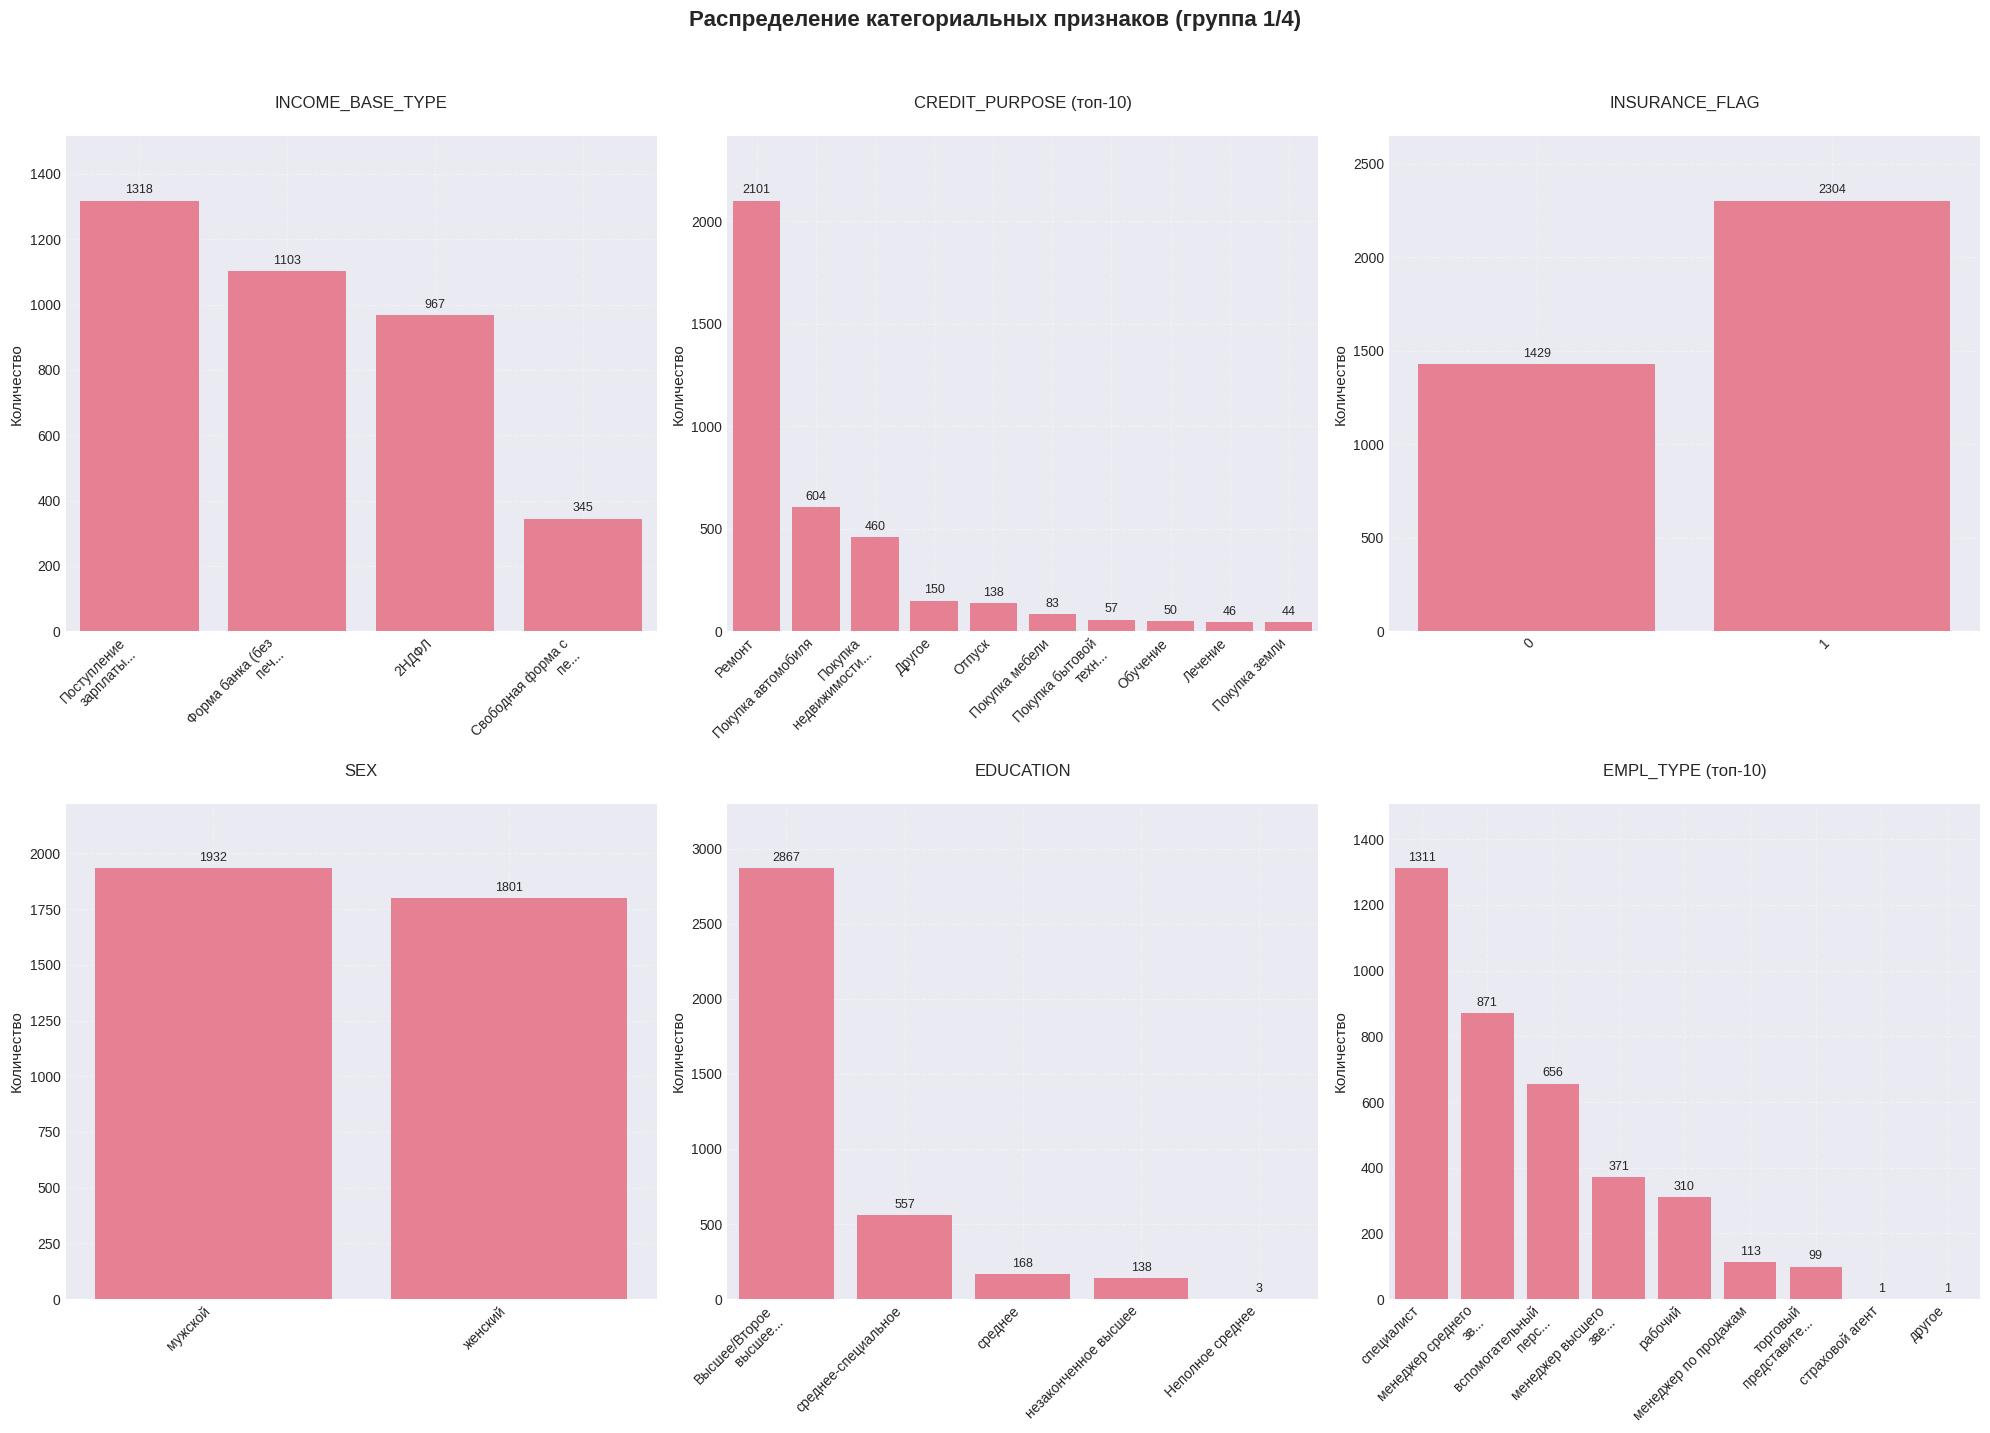

/tmp/ipykernel_42394/3065845340.py:102: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(wrapped_labels, rotation=45, ha='right', fontsize=10)
/tmp/ipykernel_42394/3065845340.py:89: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(wrapped_labels, rotation=45, ha='right', fontsize=10)
/tmp/ipykernel_42394/3065845340.py:102: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(wrapped_labels, rotation=45, ha='right', fontsize=10)
/tmp/ipykernel_42394/3065845340.py:130: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(wrapped_labels, rotation=45, ha='right', fontsize=10)
/tmp/ipykernel_42394/30658453

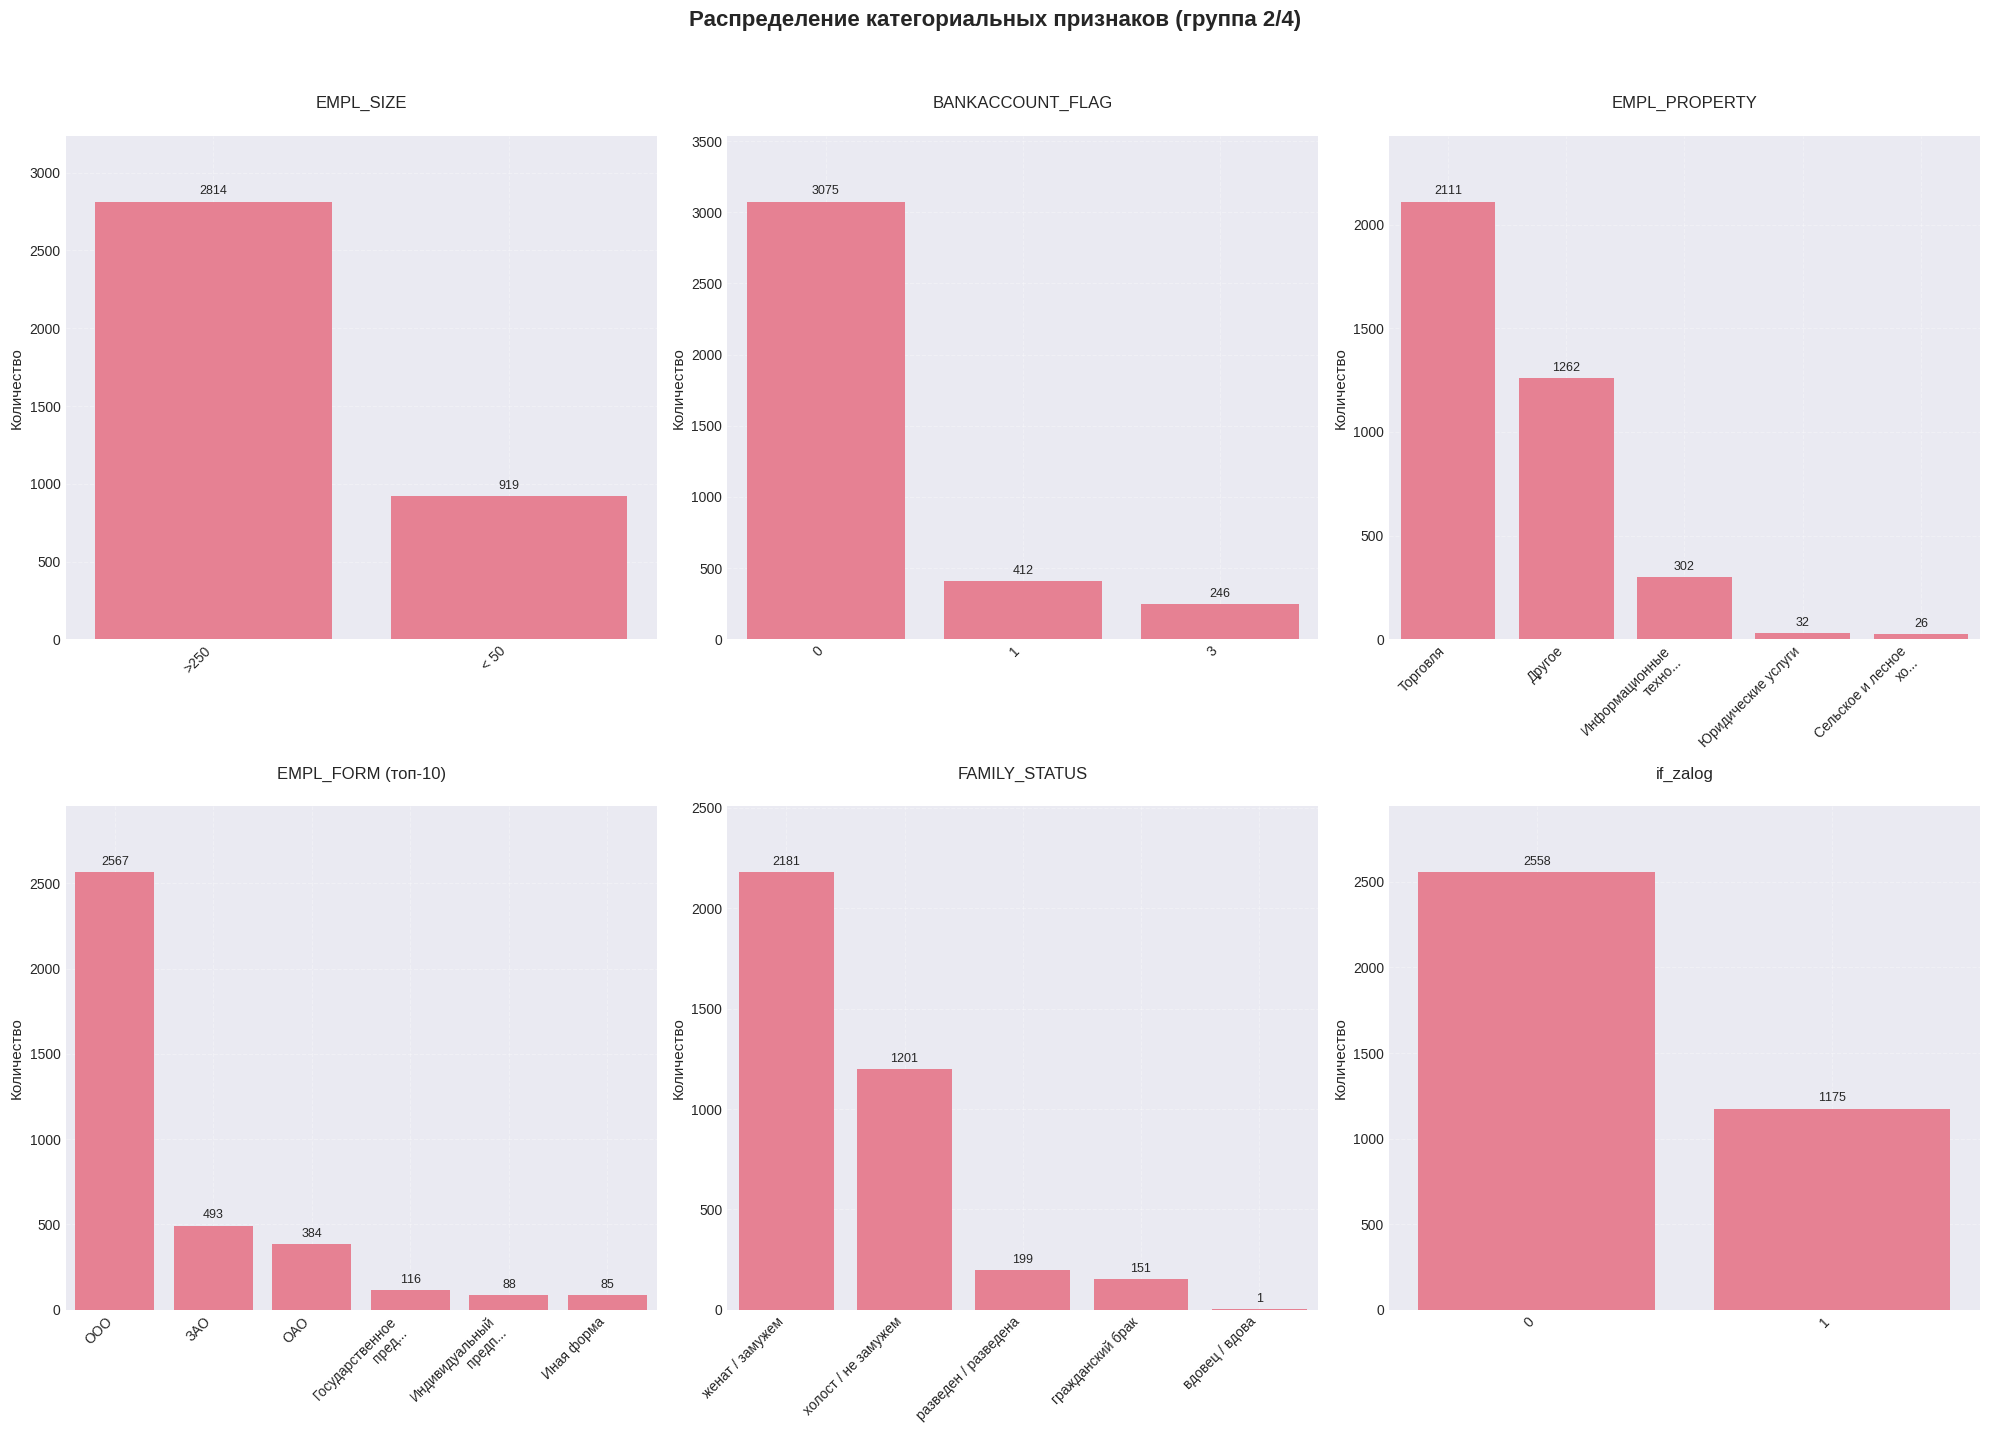

/tmp/ipykernel_42394/3065845340.py:89: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(wrapped_labels, rotation=45, ha='right', fontsize=10)
/tmp/ipykernel_42394/3065845340.py:89: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(wrapped_labels, rotation=45, ha='right', fontsize=10)
/tmp/ipykernel_42394/3065845340.py:89: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(wrapped_labels, rotation=45, ha='right', fontsize=10)
/tmp/ipykernel_42394/3065845340.py:89: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(wrapped_labels, rotation=45, ha='right', fontsize=10)
/tmp/ipykernel_42394/3065845340.

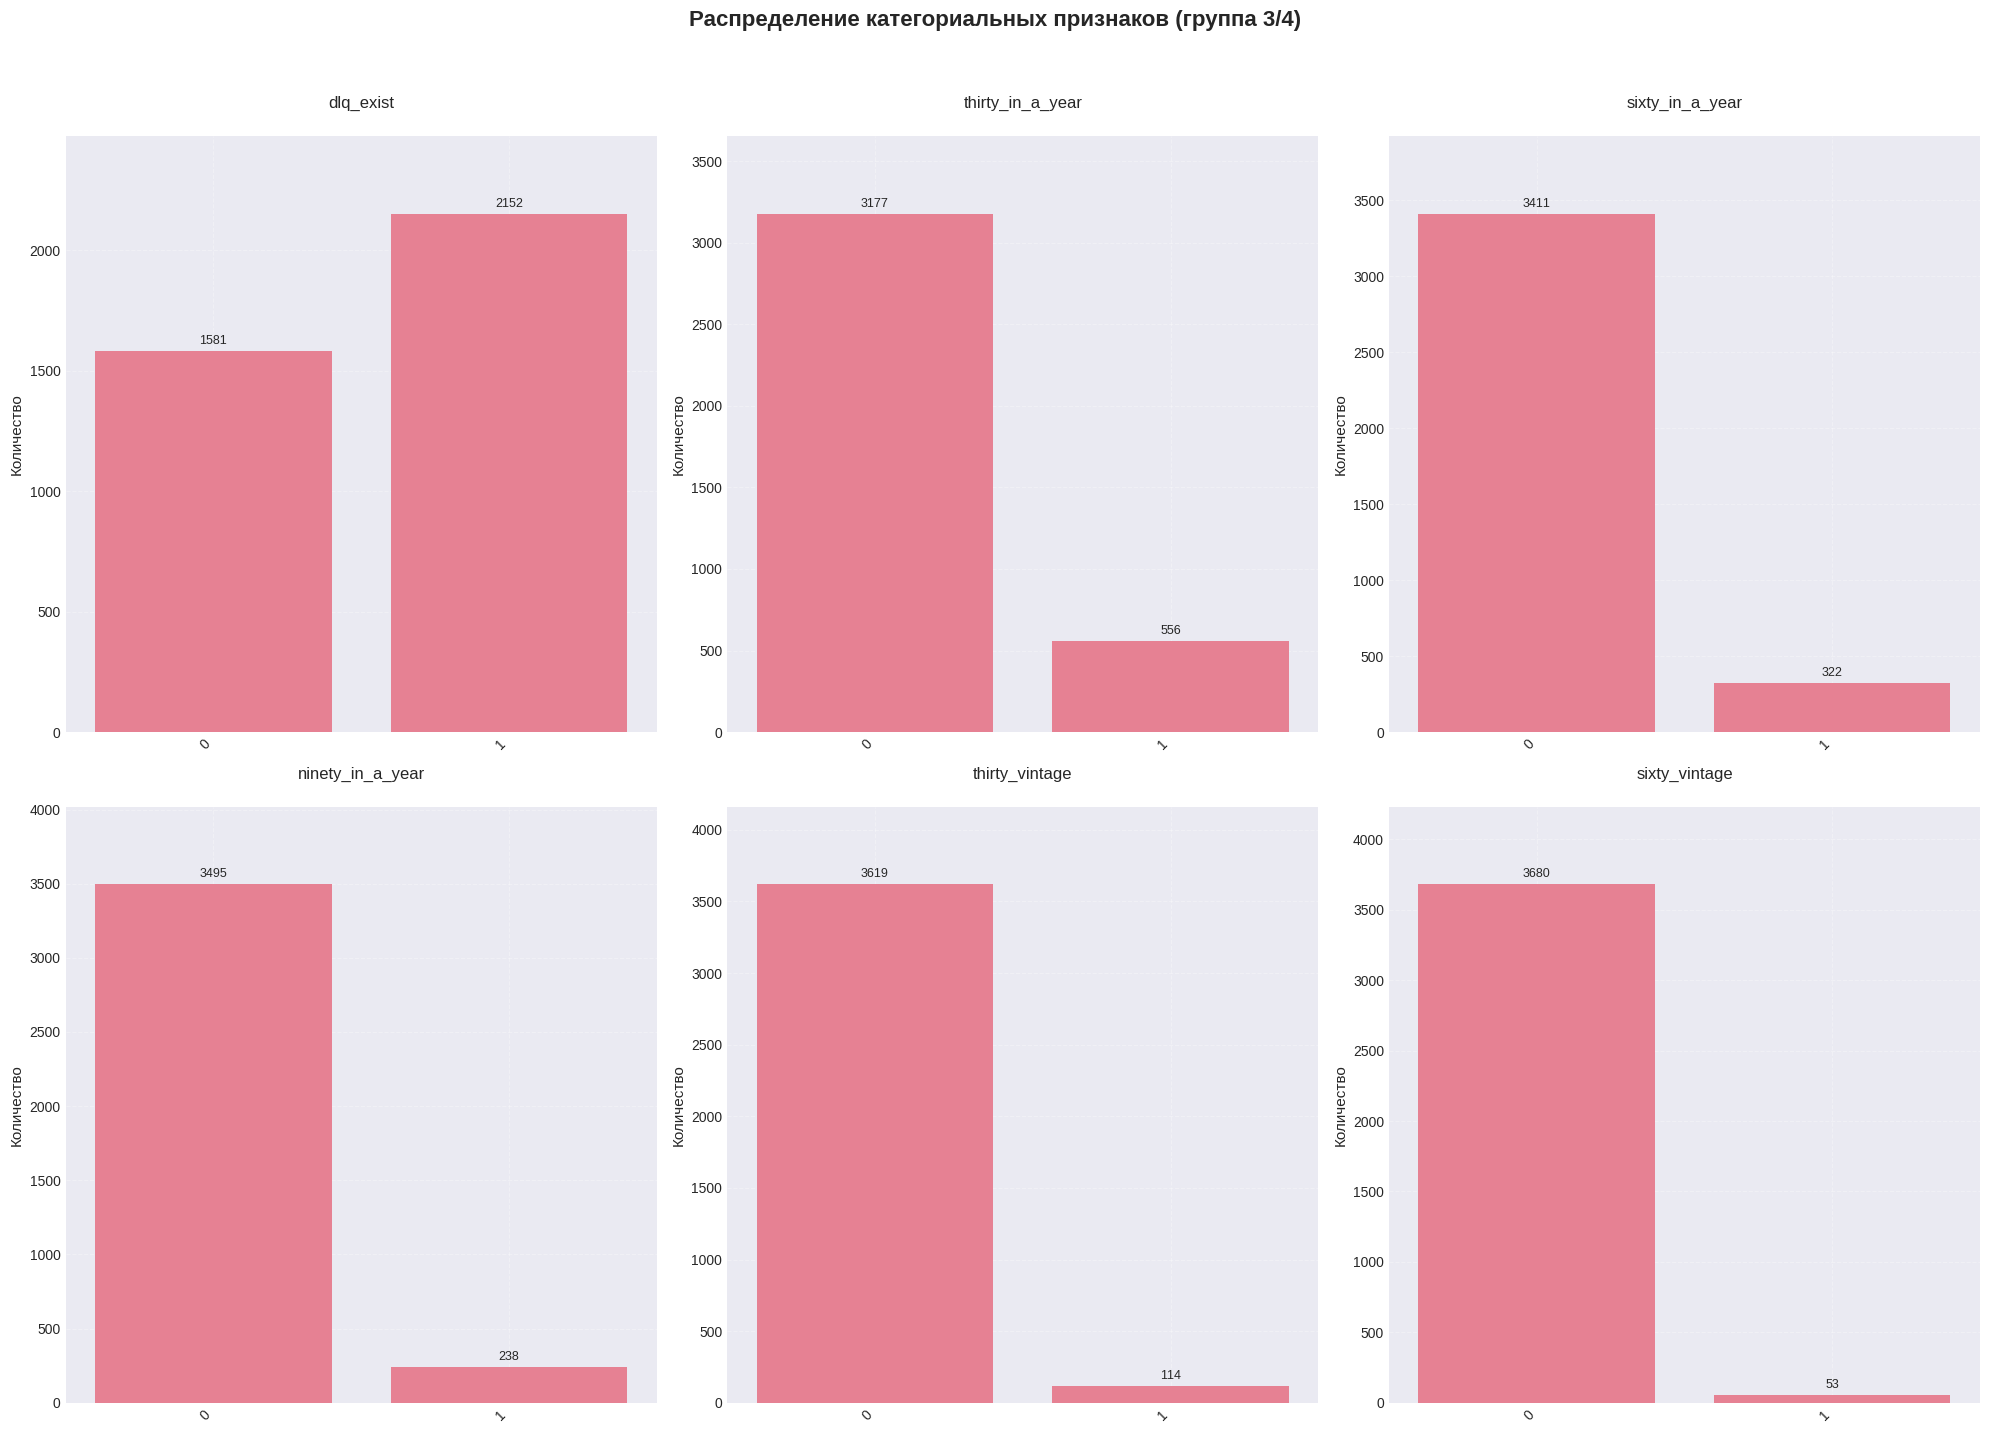

/tmp/ipykernel_42394/3065845340.py:89: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(wrapped_labels, rotation=45, ha='right', fontsize=10)


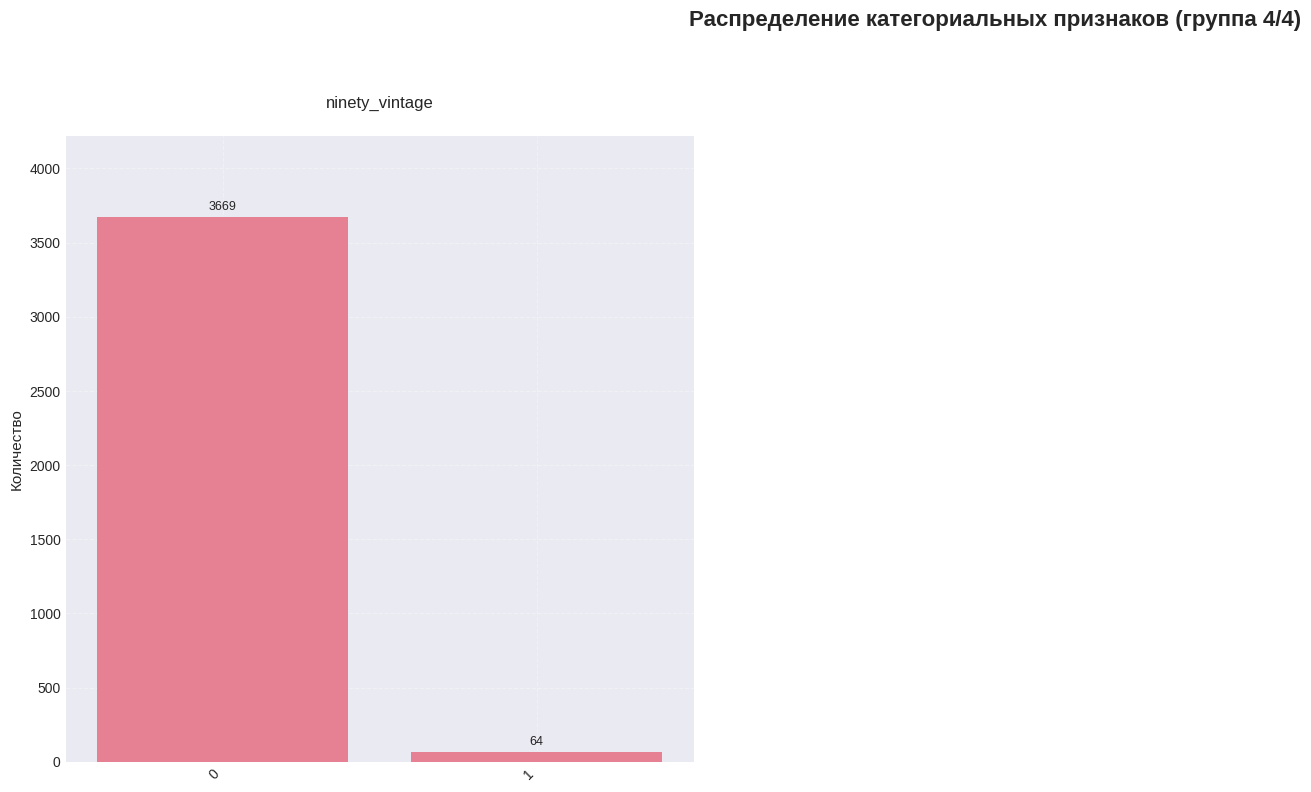



ВИЗУАЛИЗАЦИЯ КОЛИЧЕСТВЕННЫХ ПРИЗНАКОВ


/tmp/ipykernel_42394/3065845340.py:252: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


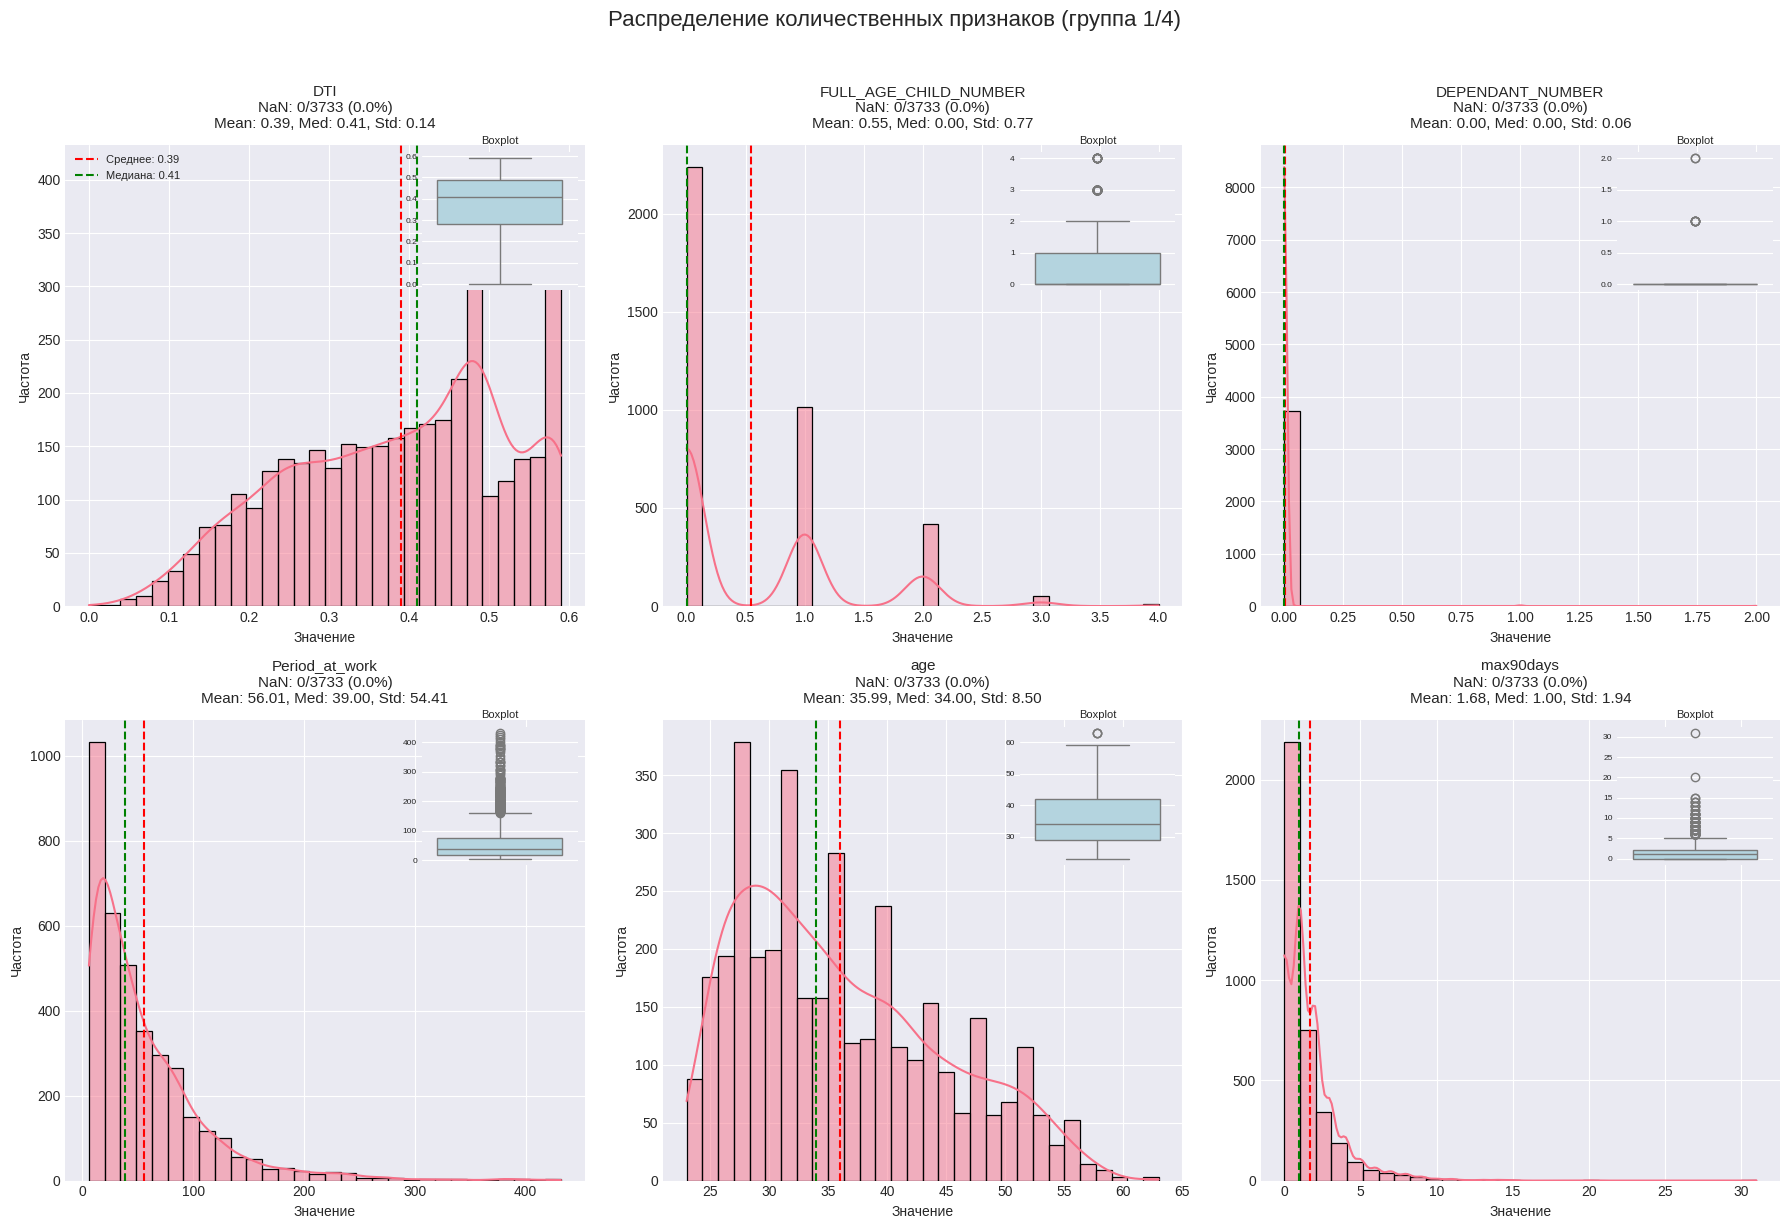

/tmp/ipykernel_42394/3065845340.py:252: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


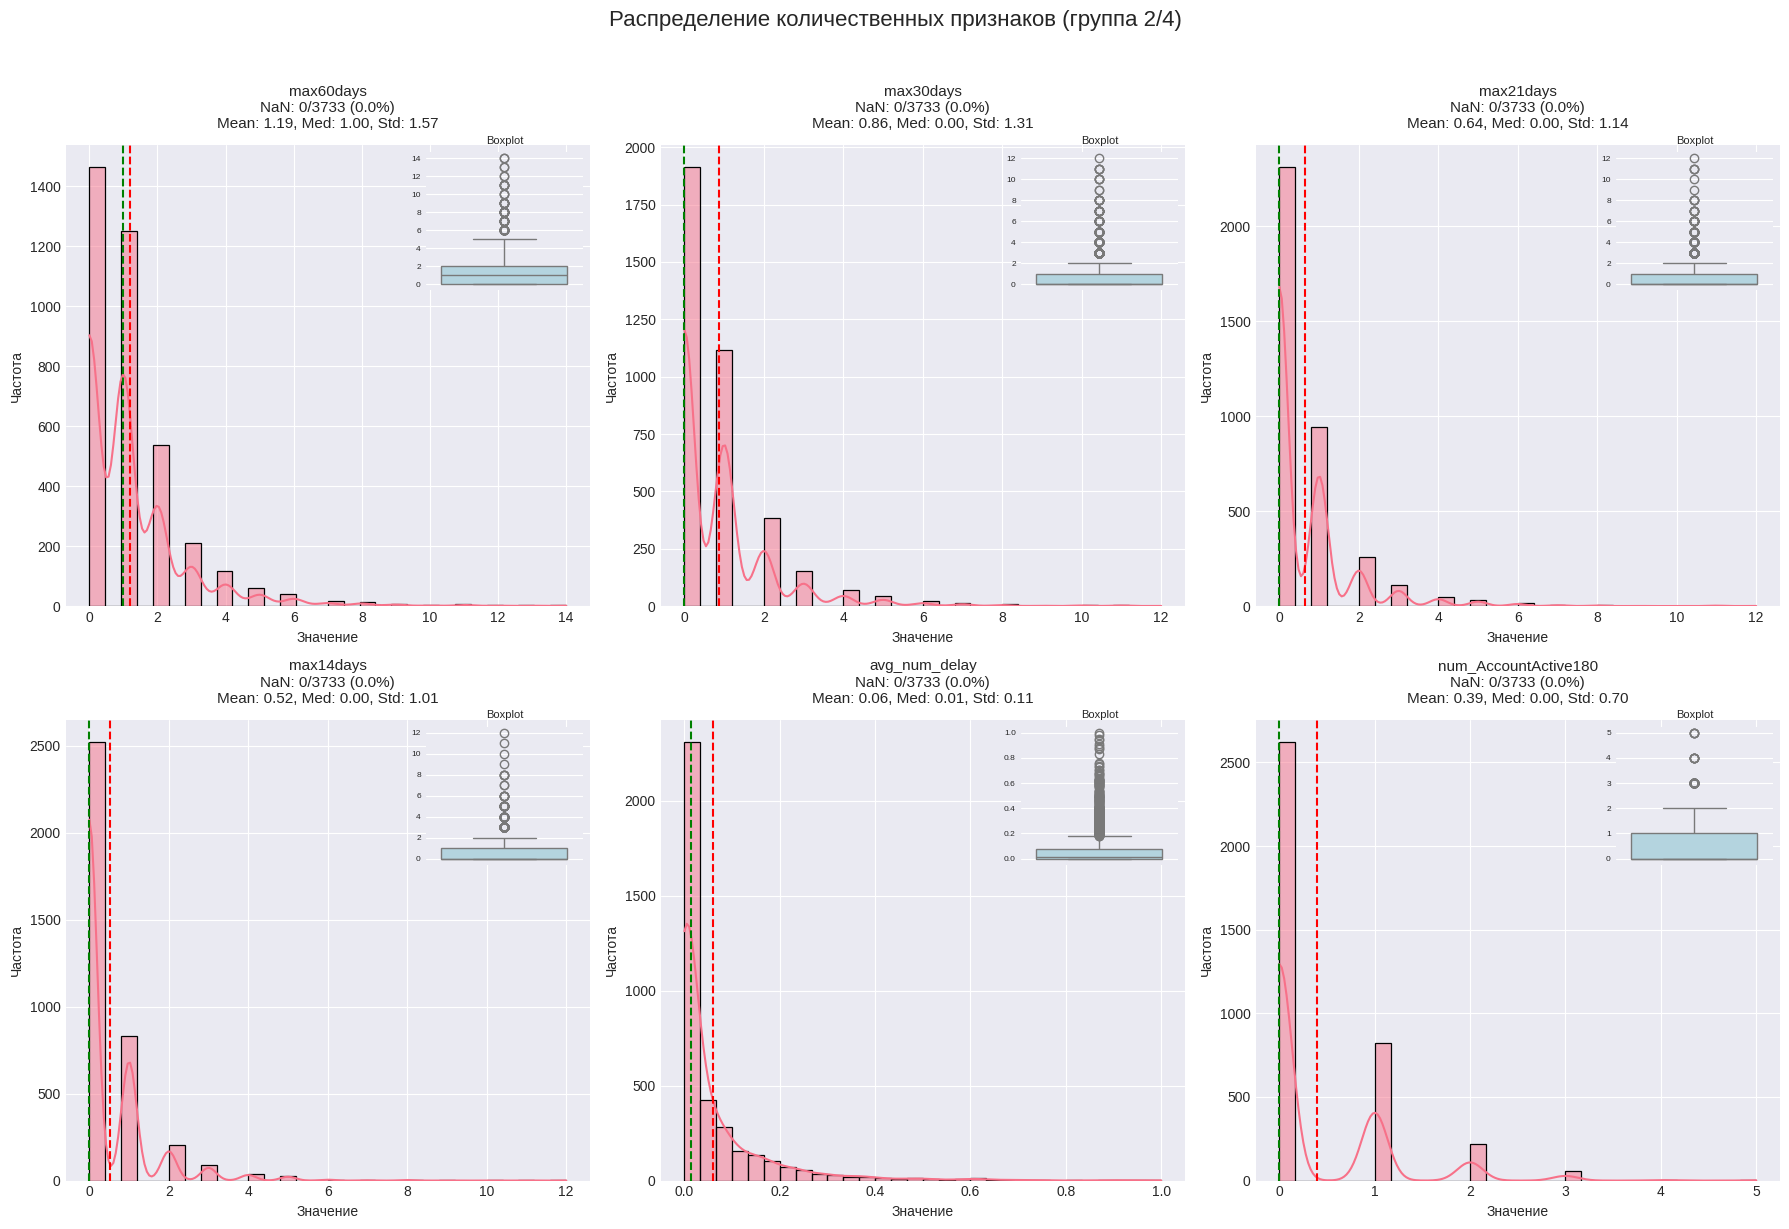

/tmp/ipykernel_42394/3065845340.py:252: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


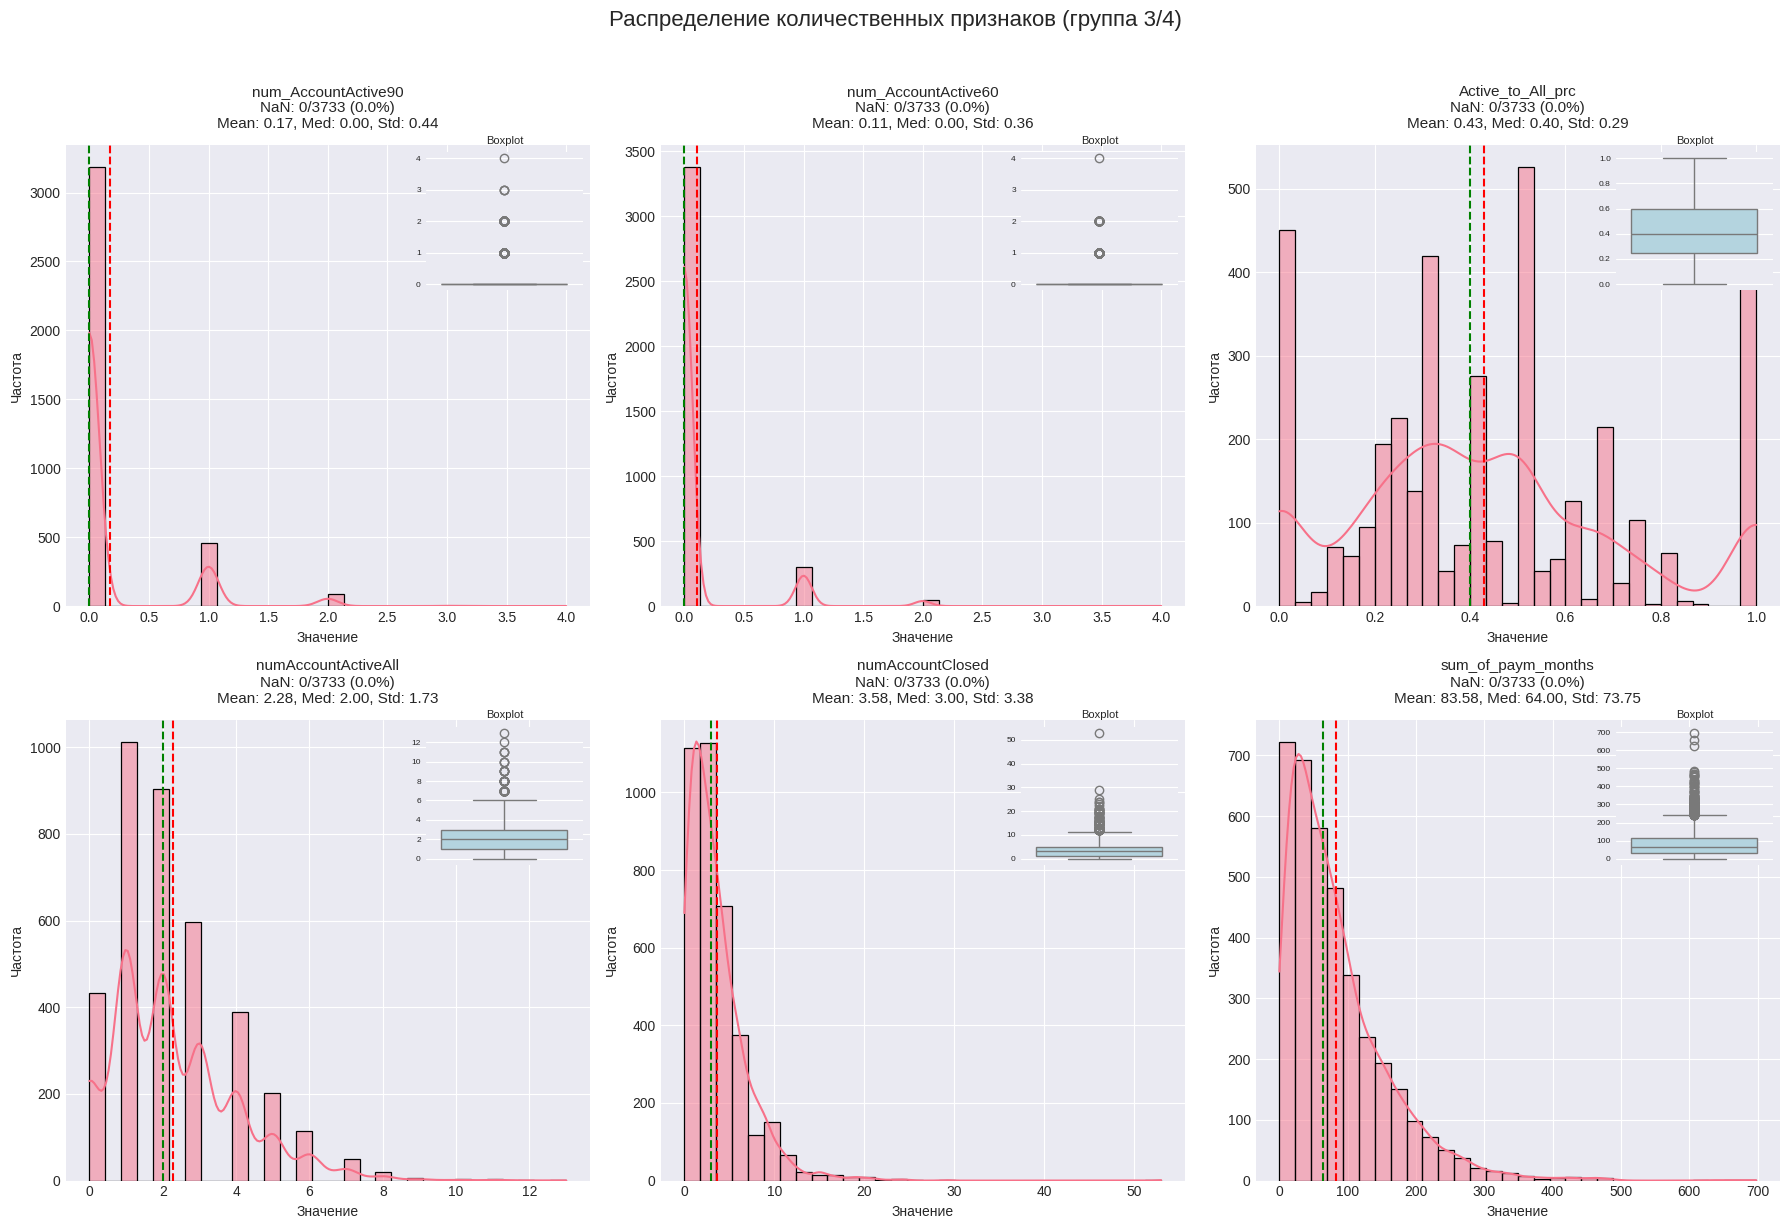

/tmp/ipykernel_42394/3065845340.py:252: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


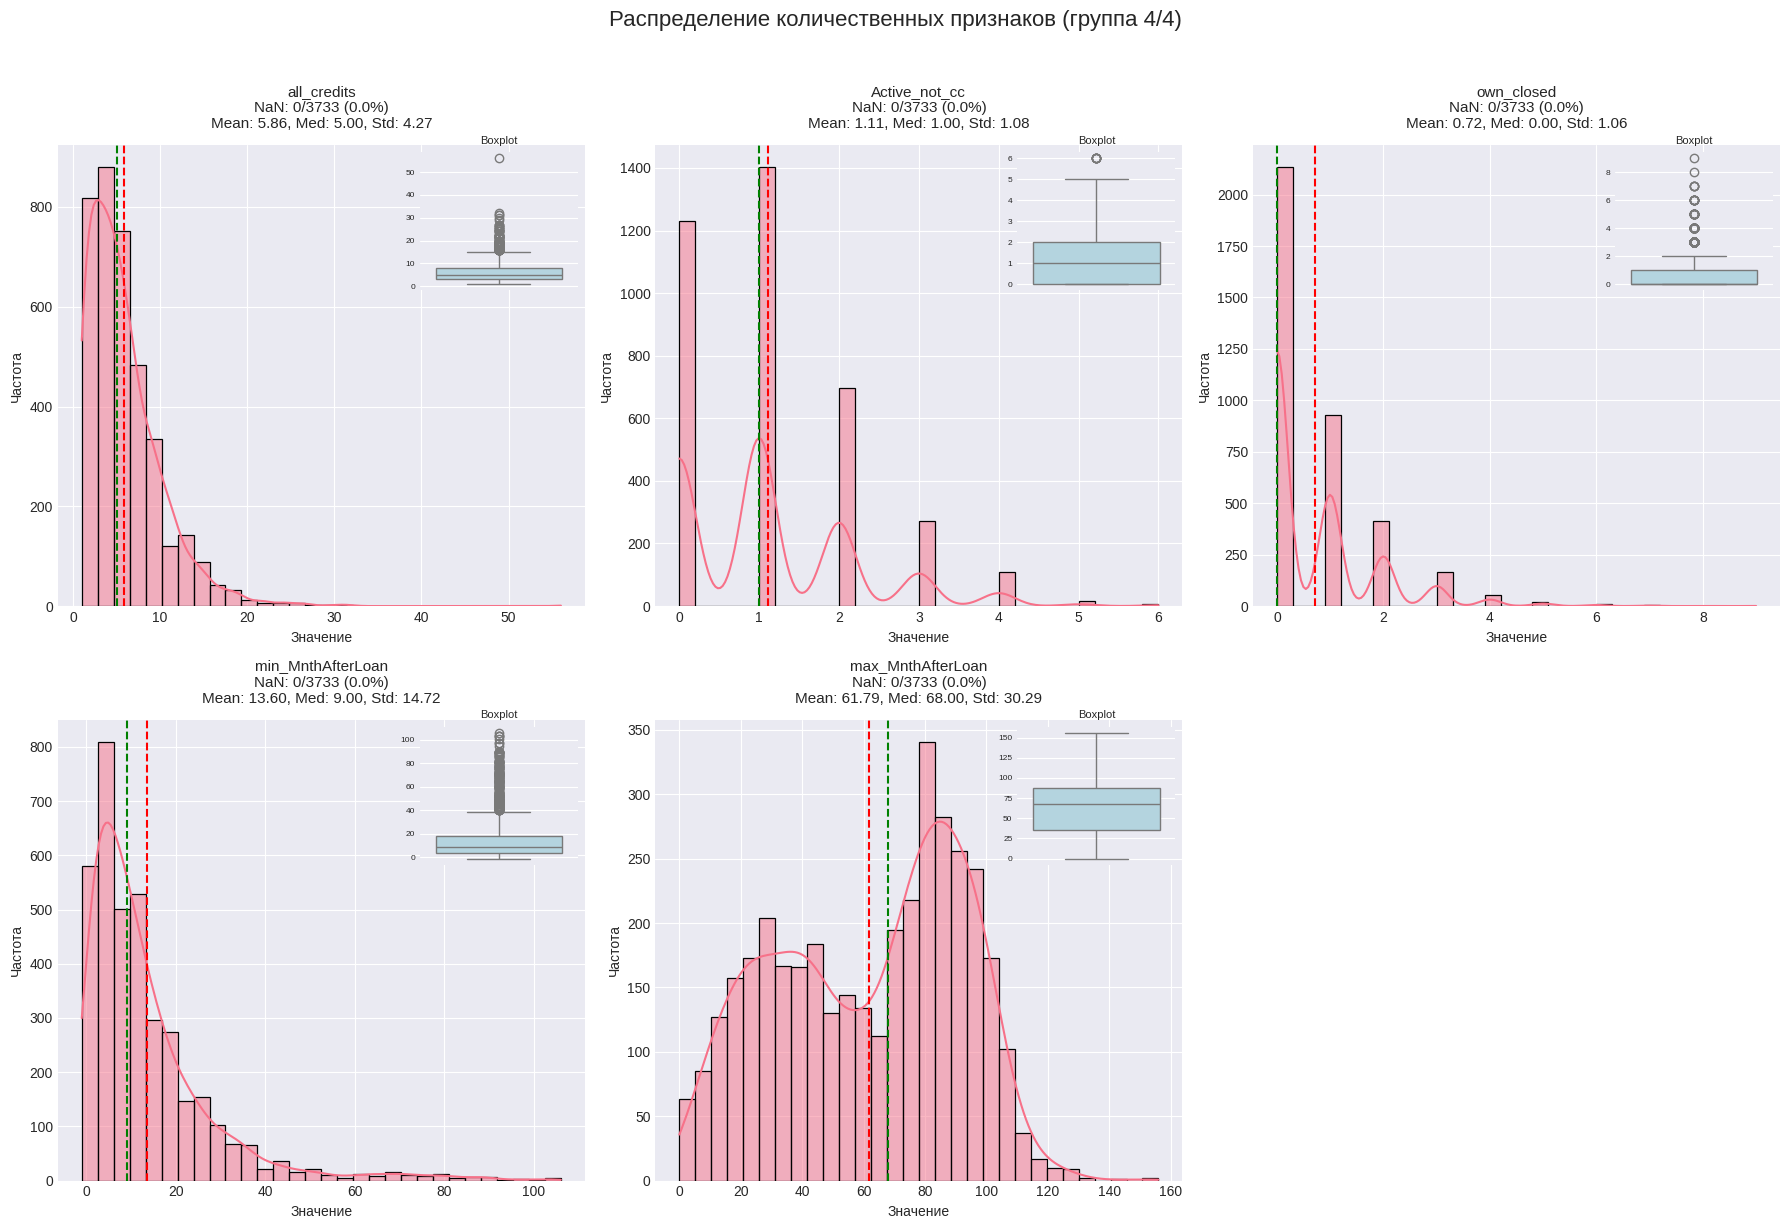



МАТРИЦА КОРРЕЛЯЦИЙ


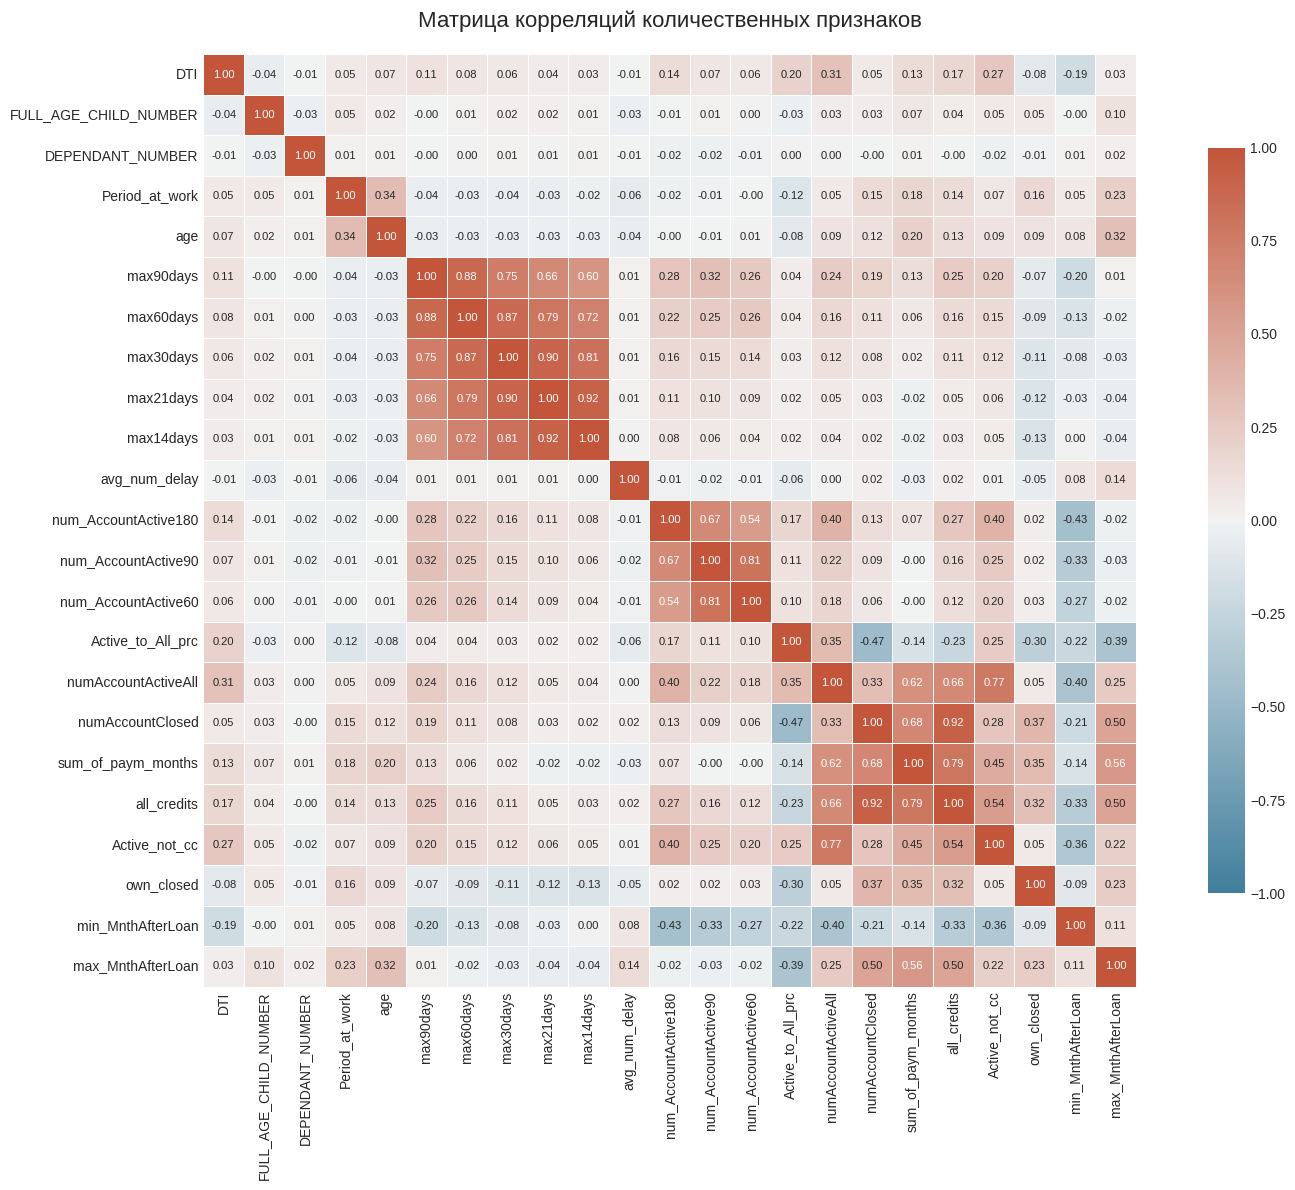


Топ-10 самых сильно коррелирующих пар:
1. numAccountClosed - all_credits: 0.924
2. all_credits - numAccountClosed: 0.924
3. max21days - max14days: 0.919
4. max14days - max21days: 0.919
5. max30days - max21days: 0.900
6. max21days - max30days: 0.900
7. max60days - max90days: 0.879
8. max90days - max60days: 0.879
9. max30days - max60days: 0.874
10. max60days - max30days: 0.874


In [1120]:
import seaborn as sns
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
import textwrap

# Устанавливаем стиль и размер графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 10)
# Списки признаков есть выше
# Проверяем, какие признаки действительно есть в данных
available_categorical = [col for col in categorical_features if col in data_copy.columns]
available_numerical = [col for col in numerical_features if col in data_copy.columns]

print(f"Доступно категориальных признаков: {len(available_categorical)} из {len(categorical_features)}")
print(f"Доступно количественных признаков: {len(available_numerical)} из {len(numerical_features)}")

def wrap_labels(labels, width=20):
    """Обернуть длинные метки для лучшего отображения"""
    wrapped_labels = []
    for label in labels:
        if isinstance(label, str):
            # Обрезаем слишком длинные строки и добавляем многоточие
            if len(label) > width:
                wrapped_labels.append(textwrap.fill(label[:width] + '...', width=width))
            else:
                wrapped_labels.append(textwrap.fill(label, width=width))
        else:
            wrapped_labels.append(str(label))
    return wrapped_labels

# Функция для визуализации распределения категориальных признаков
def plot_categorical_distributions(df, categorical_cols, max_cols_per_plot=6, label_wrap_width=20):
    """
    Визуализация распределений категориальных признаков
    
    
    Parameters:
    -----------
    df : DataFrame
        Данные
    categorical_cols : list
        Список категориальных признаков
    max_cols_per_plot : int
        Максимальное количество графиков на одной фигуре
    label_wrap_width : int
        Максимальная ширина текста в символах перед переносом
    """
    n_cols = len(categorical_cols)
    n_plots = (n_cols + max_cols_per_plot - 1) // max_cols_per_plot
    
    for plot_idx in range(n_plots):
        start_idx = plot_idx * max_cols_per_plot
        end_idx = min(start_idx + max_cols_per_plot, n_cols)
        current_cols = categorical_cols[start_idx:end_idx]
        
        fig, axes = plt.subplots(2, 3, figsize=(20, 14))  # Увеличили размер для лучшего отображения
        axes = axes.flatten()
        
        for idx, col in enumerate(current_cols):
            ax = axes[idx]
            
            if col not in df.columns:
                ax.text(0.5, 0.5, f'{col}\nне найден', 
                       ha='center', va='center', transform=ax.transAxes, fontsize=12)
                ax.set_xticks([])
                ax.set_yticks([])
                continue
            
            # Для бинарных признаков используем countplot
            if df[col].nunique() <= 5:
                # Считаем количество NaN
                nan_count = df[col].isna().sum()
                total_count = len(df[col])
                
                # Временный DataFrame без NaN для построения графика
                temp_df = df[col].dropna()
                
                if temp_df.empty:
                    ax.text(0.5, 0.5, f'{col}\nвсе значения NaN', 
                           ha='center', va='center', transform=ax.transAxes, fontsize=12)
                else:
                    # Создаем график
                    if temp_df.dtype in ['int64', 'float64']:
                        # Для числовых категориальных
                        unique_vals = sorted(temp_df.astype(str).unique())
                        wrapped_labels = wrap_labels(unique_vals, label_wrap_width)
                        sns.countplot(x=temp_df.astype(str), ax=ax, order=unique_vals)
                        ax.set_xticklabels(wrapped_labels, rotation=45, ha='right', fontsize=10)
                    else:
                        # Для строковых
                        value_counts = temp_df.value_counts()
                        if len(value_counts) > 10:
                            # Берем топ-10 значений
                            top_10 = value_counts.head(10)
                            wrapped_labels = wrap_labels(top_10.index.astype(str), label_wrap_width)
                            sns.barplot(x=top_10.index.astype(str), y=top_10.values, ax=ax)
                            ax.set_xticklabels(wrapped_labels, rotation=45, ha='right', fontsize=10)
                        else:
                            wrapped_labels = wrap_labels(value_counts.index.astype(str), label_wrap_width)
                            sns.countplot(x=temp_df, ax=ax, order=value_counts.index)
                            ax.set_xticklabels(wrapped_labels, rotation=45, ha='right', fontsize=10)
                    
                    # Улучшенный заголовок
                    title_text = f'{col}'
                    if nan_count > 0:
                        title_text += f'\nNaN: {nan_count}/{total_count} ({nan_count/total_count*100:.1f}%)'
                    
                    ax.set_title(title_text, fontsize=12, pad=20)
                    ax.set_xlabel('')
                    ax.set_ylabel('Количество', fontsize=11)
                    
                    # Улучшаем отображение значений на столбцах
                    for container in ax.containers:
                        # Автоматически определяем размер шрифта в зависимости от высоты столбца
                        max_height = max([rect.get_height() for rect in container])
                        font_size = 9 if max_height > 1000 else 10
                        ax.bar_label(container, fmt='%d', padding=3, fontsize=font_size)
                    
                    # Автоматически регулируем пределы оси Y для размещения меток
                    y_max = max([rect.get_height() for rect in container for container in ax.containers])
                    ax.set_ylim(0, y_max * 1.15)  # Добавляем 15% сверху для меток
                    
            else:
                # Для признаков с большим количеством уникальных значений
                value_counts = df[col].dropna().value_counts().head(10)
                if len(value_counts) > 0:
                    wrapped_labels = wrap_labels(value_counts.index.astype(str), label_wrap_width)
                    sns.barplot(x=value_counts.index.astype(str), y=value_counts.values, ax=ax)
                    ax.set_xticklabels(wrapped_labels, rotation=45, ha='right', fontsize=10)
                    
                    # Улучшенный заголовок
                    nan_count = df[col].isna().sum()
                    total_count = len(df[col])
                    title_text = f'{col} (топ-10)'
                    if nan_count > 0:
                        title_text += f'\nNaN: {nan_count}/{total_count} ({nan_count/total_count*100:.1f}%)'
                    
                    ax.set_title(title_text, fontsize=12, pad=20)
                    ax.set_xlabel('')
                    ax.set_ylabel('Количество', fontsize=11)
                    
                    # Добавляем значения на столбцы
                    for container in ax.containers:
                        max_height = max([rect.get_height() for rect in container])
                        font_size = 9 if max_height > 1000 else 10
                        ax.bar_label(container, fmt='%d', padding=3, fontsize=font_size)
                    
                    # Регулируем пределы оси Y
                    y_max = max([rect.get_height() for rect in container for container in ax.containers])
                    ax.set_ylim(0, y_max * 1.15)
                else:
                    ax.text(0.5, 0.5, f'{col}\nнет данных', 
                           ha='center', va='center', transform=ax.transAxes, fontsize=12)
            
            # Улучшаем сетку
            ax.grid(True, alpha=0.3, linestyle='--')
        
        # Скрываем неиспользованные оси
        for idx in range(len(current_cols), len(axes)):
            axes[idx].set_visible(False)
        
        plt.suptitle(f'Распределение категориальных признаков (группа {plot_idx + 1}/{n_plots})', 
                    fontsize=16, y=1.02, fontweight='bold')
        plt.tight_layout()
        plt.subplots_adjust(top=0.93)  # Добавляем место для заголовка
        plt.show()



# Функция для визуализации распределения количественных признаков
def plot_numerical_distributions(df, numerical_cols, max_cols_per_plot=6):
    """
    Визуализация распределений количественных признаков
    
    Parameters:
    -----------
    df : DataFrame
        Данные
    numerical_cols : list
        Список количественных признаков
    max_cols_per_plot : int
        Максимальное количество графиков на одной фигуре
    """
    n_cols = len(numerical_cols)
    n_plots = (n_cols + max_cols_per_plot - 1) // max_cols_per_plot
    
    for plot_idx in range(n_plots):
        start_idx = plot_idx * max_cols_per_plot
        end_idx = min(start_idx + max_cols_per_plot, n_cols)
        current_cols = numerical_cols[start_idx:end_idx]
        
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        axes = axes.flatten()
        
        for idx, col in enumerate(current_cols):
            ax = axes[idx]
            
            if col not in df.columns:
                ax.text(0.5, 0.5, f'{col}\nне найден', 
                       ha='center', va='center', transform=ax.transAxes)
                ax.set_xticks([])
                ax.set_yticks([])
                continue
            
            # Проверяем на наличие данных
            valid_data = df[col].dropna()
            nan_count = df[col].isna().sum()
            total_count = len(df[col])
            
            if len(valid_data) == 0:
                ax.text(0.5, 0.5, f'{col}\nвсе значения NaN', 
                       ha='center', va='center', transform=ax.transAxes)
                ax.set_xticks([])
                ax.set_yticks([])
            else:
                # Создаем гистограмму с KDE
                sns.histplot(data=valid_data, kde=True, ax=ax, bins=30)
                
                # Добавляем вертикальную линию для среднего
                mean_val = valid_data.mean()
                median_val = valid_data.median()
                ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, 
                          label=f'Среднее: {mean_val:.2f}')
                ax.axvline(median_val, color='green', linestyle='--', linewidth=1.5,
                          label=f'Медиана: {median_val:.2f}')
                
                # Статистики в заголовке
                stats_text = (f'{col}\n'
                             f'NaN: {nan_count}/{total_count} ({nan_count/total_count*100:.1f}%)\n'
                             f'Mean: {mean_val:.2f}, Med: {median_val:.2f}, Std: {valid_data.std():.2f}')
                ax.set_title(stats_text, fontsize=11, pad=12)
                ax.set_xlabel('Значение')
                ax.set_ylabel('Частота')
                ax.legend(fontsize=8)
                
                # Добавляем boxplot на той же оси (инсет)
                from mpl_toolkits.axes_grid1.inset_locator import inset_axes
                ax_inset = inset_axes(ax, width="30%", height="30%", loc='upper right')
                sns.boxplot(y=valid_data, ax=ax_inset, color='lightblue')
                ax_inset.set_xlabel('')
                ax_inset.set_ylabel('')
                ax_inset.set_title('Boxplot', fontsize=8)
                ax_inset.tick_params(labelsize=6)
        
        # Скрываем неиспользованные оси
        for idx in range(len(current_cols), len(axes)):
            axes[idx].set_visible(False)
        
        plt.suptitle(f'Распределение количественных признаков (группа {plot_idx + 1}/{n_plots})', 
                    fontsize=16, y=1.02)
        plt.tight_layout()
        plt.show()

# Функция для сводной статистики
def print_numerical_summary(df, numerical_cols):
    """
    Вывод сводной статистики по количественным признакам
    """
    print("=" * 80)
    print("СВОДНАЯ СТАТИСТИКА КОЛИЧЕСТВЕННЫХ ПРИЗНАКОВ")
    print("=" * 80)
    
    for col in numerical_cols:
        if col in df.columns:
            valid_data = df[col].dropna()
            if len(valid_data) > 0:
                print(f"\n{col}:")
                print(f"  Количество значений: {len(valid_data)} (NaN: {df[col].isna().sum()})")
                print(f"  Минимум: {valid_data.min():.2f}")
                print(f"  25-й перцентиль: {valid_data.quantile(0.25):.2f}")
                print(f"  Медиана: {valid_data.median():.2f}")
                print(f"  Среднее: {valid_data.mean():.2f}")
                print(f"  75-й перцентиль: {valid_data.quantile(0.75):.2f}")
                print(f"  Максимум: {valid_data.max():.2f}")
                print(f"  Стандартное отклонение: {valid_data.std():.2f}")
                print(f"  Коэффициент вариации: {(valid_data.std()/valid_data.mean()*100 if valid_data.mean() != 0 else np.inf):.2f}%")
                print(f"  Skewness: {valid_data.skew():.2f}")
                print(f"  Kurtosis: {valid_data.kurtosis():.2f}")

# Функция для сводной статистики категориальных признаков
def print_categorical_summary(df, categorical_cols):
    """
    Вывод сводной статистики по категориальным признакам
    """
    print("=" * 80)
    print("СВОДНАЯ СТАТИСТИКА КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")
    print("=" * 80)
    
    for col in categorical_cols:
        if col in df.columns:
            valid_data = df[col].dropna()
            if len(valid_data) > 0:
                print(f"\n{col}:")
                print(f"  Количество значений: {len(valid_data)} (NaN: {df[col].isna().sum()})")
                print(f"  Уникальных значений: {valid_data.nunique()}")
                print(f"  Наиболее частое значение: {valid_data.mode().iloc[0] if not valid_data.mode().empty else 'N/A'}")
                print(f"  Частота наиболее частого: {valid_data.value_counts().iloc[0] if len(valid_data.value_counts()) > 0 else 0}")
                
                if valid_data.nunique() <= 10:
                    print("  Распределение:")
                    for value, count in valid_data.value_counts().head(10).items():
                        percentage = count / len(valid_data) * 100
                        print(f"    {value}: {count} ({percentage:.1f}%)")

# Функция для матрицы корреляций (только для количественных признаков)
def plot_correlation_matrix(df, numerical_cols):
    """
    Построение тепловой карты корреляций
    """
    # Выбираем только существующие колонки
    existing_cols = [col for col in numerical_cols if col in df.columns]
    
    if len(existing_cols) < 2:
        print("Недостаточно количественных признаков для построения матрицы корреляций")
        return
    
    # Создаем матрицу корреляций
    corr_matrix = df[existing_cols].corr()
    
    # Создаем маску для верхнего треугольника
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    # Строим тепловую карту
    plt.figure(figsize=(16, 12))
    cmap = sns.diverging_palette(230, 20, as_cmap=True)
    
    sns.heatmap(corr_matrix, 
                #mask=mask, 
                cmap=cmap, vmax=1, vmin=-1, center=0,
                square=True, linewidths=.5, cbar_kws={"shrink": .8}, 
                annot=True, fmt='.2f', annot_kws={'size': 8})
    
    plt.title('Матрица корреляций количественных признаков', fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()
    
    # Выводим топ коррелирующих пар
    print("\nТоп-10 самых сильно коррелирующих пар:")
    corr_pairs = corr_matrix.unstack()
    corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]
    sorted_pairs = corr_pairs.abs().sort_values(ascending=False).head(10)
    
    for idx, (pair, corr_value) in enumerate(sorted_pairs.items(), 1):
        if corr_value > 0.5:  # Показываем только сильные корреляции
            print(f"{idx}. {pair[0]} - {pair[1]}: {corr_matrix.loc[pair[0], pair[1]]:.3f}")


# 1. Распределение категориальных признаков
print("ВИЗУАЛИЗАЦИЯ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")
plot_categorical_distributions(data_copy, available_categorical, max_cols_per_plot=6)

# 2. Сводная статистика по категориальным признакам
#print_categorical_summary(data_copy, available_categorical)

# 3. Распределение количественных признаков
print("\n\nВИЗУАЛИЗАЦИЯ КОЛИЧЕСТВЕННЫХ ПРИЗНАКОВ")
plot_numerical_distributions(data_copy, available_numerical, max_cols_per_plot=6)

# 4. Сводная статистика по количественным признакам
#print_numerical_summary(data_copy, available_numerical)

# 5. Матрица корреляций
print("\n\nМАТРИЦА КОРРЕЛЯЦИЙ")
plot_correlation_matrix(data_copy, available_numerical)

In [97]:
print(f'Кол-во строк = {data_copy.shape[0]}, кол-во столбцов = {data_copy.shape[1]}')

Кол-во строк = 3733, кол-во столбцов = 43


Есть признаки с сильной корреляцией:
- max90days - кол-во запросов в бюро кредитных историй за последние 90 дней
- max60days - кол-во запросов в бюро кредитных историй за последние 60 дней
- max30days - кол-во запросов в бюро кредитных историй за последние 30 дней
- max21days - кол-во запросов в бюро кредитных историй за последние 21 дней
- max14days - кол-во запросов в бюро кредитных историй за последние 14 дней

-> оставим только один, например:
- max60days - кол-во запросов в бюро кредитных историй за последние 60 дней

Аналогичная ситуация наблюдается для признаков:
- num_AccountActive180 - кол-во активных счетов счетов за последние 180 дней
- num_AccountActive90 - кол-во активных счетов счетов за последние 90 дней
- num_AccountActive60 - кол-во активных счетов счетов за последние 60 дней

-> оставим только num_AccountActive60 

Также есть признаки, которые являются производными от других:
- Active_to_All_prc - отношение активных счетов ко всем счетам - это отношение numAccountActiveAll (кол-во открытых счетоа) к all_credits (Кол-во кредитов)
- all_credits = numAccountActiveAll + numAccountClosed - между ними высокая корреляция -> удалим all_credits

Есть высокая корреляция между признаками sum_of_paym_months и all_credits/numAccountClosed/numAccountActiveAll, что логично, так как чем больше кредитов, тем выше сумма платежа
-> этот признак также удалим

Наблюдается высокая корреляция (0,77) между признаками Active_not_cc и numAccountActiveAll
-> создадим производный признак "Есть или нет активная кредитная карта" и удалим признак Active_not_cc

In [1124]:
data_copy['exists_active_cc'] = 0
data_copy.loc[(data_copy['numAccountActiveAll'] - data_copy['Active_not_cc'])>0, 'exists_active_cc'] = 1

In [1125]:
#Какие количественные признаки останутся
available_numerical = [
    'DTI',
# 'FULL_AGE_CHILD_NUMBER',
# 'DEPENDANT_NUMBER',
 'Period_at_work',
 'age',
 'max90days',
# 'max60days',
# 'max30days',
# 'max21days',
# 'max14days',
 'avg_num_delay',
# 'num_AccountActive180',
 'num_AccountActive90',
# 'num_AccountActive60',
 'Active_to_All_prc',
 'numAccountActiveAll',
 'numAccountClosed',
# 'sum_of_paym_months',
# 'all_credits',
# 'Active_not_cc',
 'own_closed',
 'min_MnthAfterLoan',
 'max_MnthAfterLoan']

In [1126]:
#Какие количественные признаки останутся
available_numerical = ['DTI',
 'FULL_AGE_CHILD_NUMBER',
 'DEPENDANT_NUMBER',
 'Period_at_work',
 'age',
 'max90days',
 'max60days',
 'max30days',
 'max21days',
 'max14days',
 'avg_num_delay',
 'num_AccountActive180',
 'num_AccountActive90',
 'num_AccountActive60',
 'Active_to_All_prc',
 'numAccountActiveAll',
 'numAccountClosed',
 'sum_of_paym_months',
 'all_credits',
 'Active_not_cc',
 'own_closed',
 'min_MnthAfterLoan',
 'max_MnthAfterLoan']



МАТРИЦА КОРРЕЛЯЦИЙ


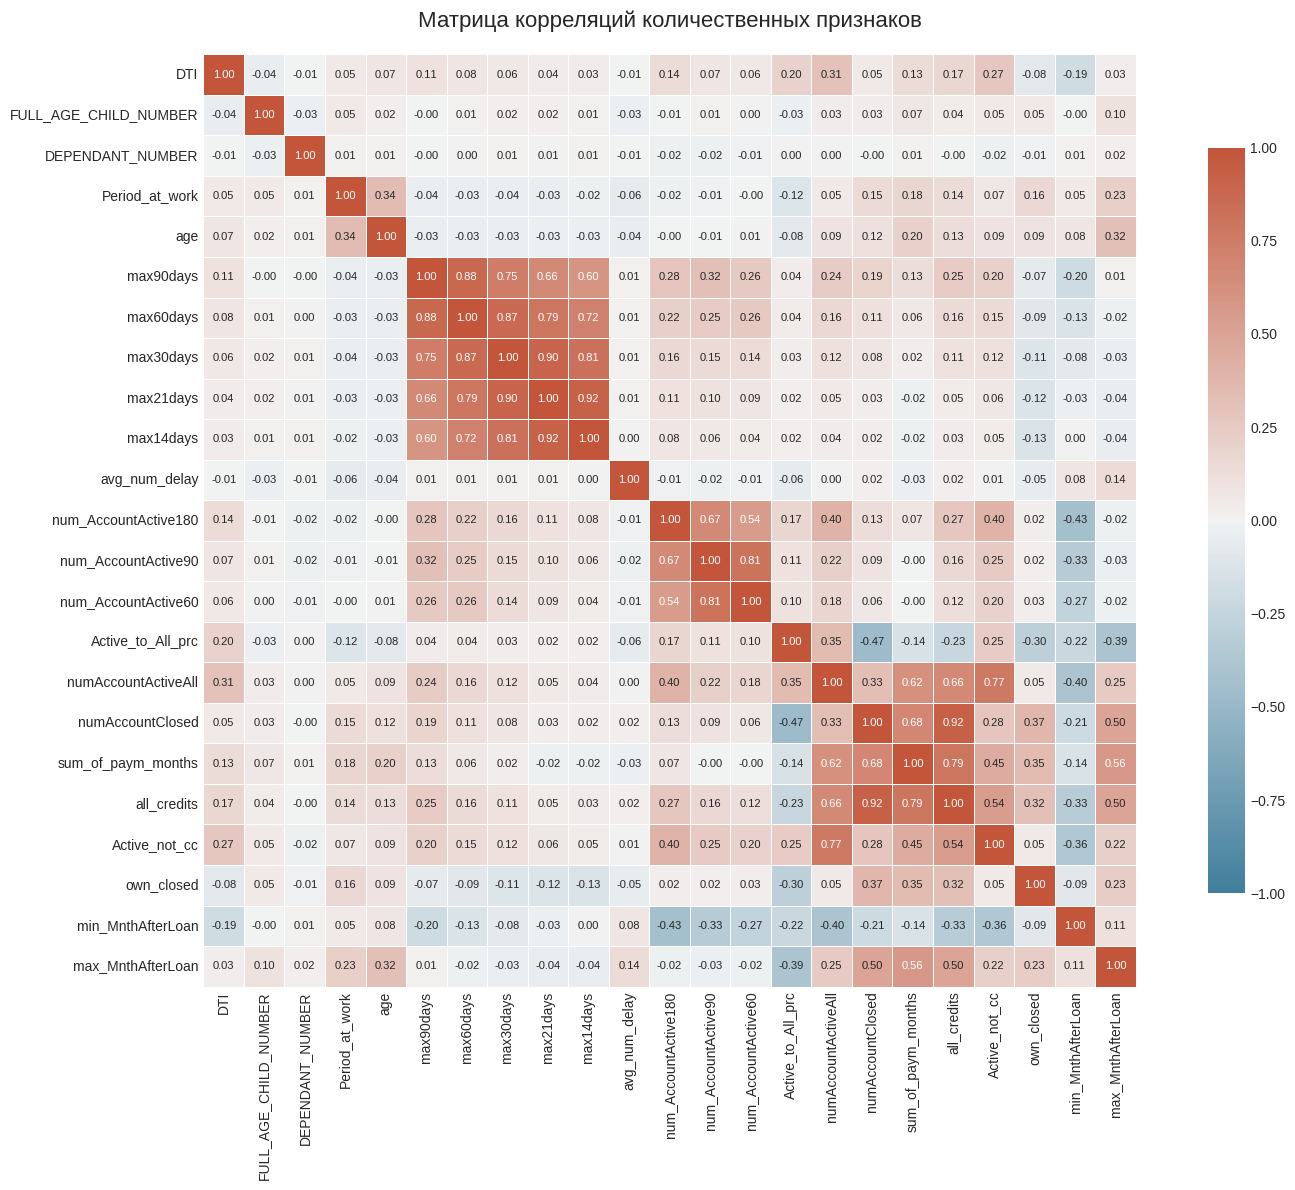


Топ-10 самых сильно коррелирующих пар:
1. numAccountClosed - all_credits: 0.924
2. all_credits - numAccountClosed: 0.924
3. max21days - max14days: 0.919
4. max14days - max21days: 0.919
5. max30days - max21days: 0.900
6. max21days - max30days: 0.900
7. max60days - max90days: 0.879
8. max90days - max60days: 0.879
9. max30days - max60days: 0.874
10. max60days - max30days: 0.874


In [1127]:
print("\n\nМАТРИЦА КОРРЕЛЯЦИЙ")
plot_correlation_matrix(data_copy, available_numerical)

#### Посмотрим также корреляцию между ВСЕМИ признаками

In [1128]:
df_encoded

,ID,INCOME_BASE_TYPE,CREDIT_PURPOSE,INSURANCE_FLAG,DTI,SEX,FULL_AGE_CHILD_NUMBER,DEPENDANT_NUMBER,EDUCATION,EMPL_TYPE,EMPL_SIZE,BANKACCOUNT_FLAG,Period_at_work,age,EMPL_PROPERTY,EMPL_FORM,FAMILY_STATUS,max90days,max60days,max30days,max21days,max14days,avg_num_delay,if_zalog,num_AccountActive180,num_AccountActive90,num_AccountActive60,Active_to_All_prc,numAccountActiveAll,numAccountClosed,sum_of_paym_months,all_credits,Active_not_cc,own_closed,min_MnthAfterLoan,max_MnthAfterLoan,dlq_exist,thirty_in_a_year,sixty_in_a_year,ninety_in_a_year,thirty_vintage,sixty_vintage,ninety_vintage,rate_active_cc,rate_not_active_cc,exists_active_cc
0,1000031,3,1,1,0.49,0,0,0,6,0,1,0,109.0,46.0,3,1,5,3.0,2.0,2.0,1.0,0.0,0.089109,0,0.0,0.0,0.0,0.600000,3.0,2.0,92.0,5.0,2.0,1.0,17.0,43.0,1,0,0,0,0,0,0,0.666667,0.666667,1
1,1000051,0,0,1,0.59,0,0,0,6,0,1,0,47.0,47.0,3,5,5,1.0,0.0,0.0,0.0,0.0,0.006369,1,0.0,0.0,0.0,0.555556,5.0,4.0,156.0,9.0,3.0,1.0,18.0,89.0,1,0,0,0,0,0,0,0.600000,0.600000,1
2,1000071,1,4,1,0.36,1,0,0,3,6,1,0,32.0,27.0,1,5,5,0.0,0.0,0.0,0.0,0.0,0.000000,0,0.0,0.0,0.0,0.000000,0.0,1.0,7.0,1.0,0.0,1.0,32.0,32.0,0,0,0,0,0,0,0,NaN,NaN,0
3,1000271,1,8,1,0.50,1,0,0,3,4,1,0,6.0,53.0,3,1,5,0.0,0.0,0.0,0.0,0.0,0.000000,0,2.0,0.0,0.0,0.500000,3.0,3.0,46.0,6.0,2.0,3.0,3.0,28.0,0,0,0,0,0,0,0,0.666667,0.666667,1
4,1000311,2,4,0,0.47,1,1,0,3,5,1,0,53.0,26.0,0,4,2,3.0,2.0,2.0,2.0,1.0,0.023622,1,0.0,0.0,0.0,0.375000,3.0,5.0,124.0,8.0,2.0,0.0,8.0,50.0,1,0,0,0,0,0,0,0.666667,0.666667,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3740,1204591,2,4,1,0.36,1,1,0,3,5,1,0,31.0,32.0,3,5,3,1.0,1.0,1.0,1.0,1.0,0.000000,0,1.0,0.0,0.0,0.250000,1.0,3.0,22.0,4.0,1.0,0.0,3.0,24.0,0,0,0,0,0,0,0,1.000000,1.000000,0
3741,1204631,1,8,1,0.46,1,0,0,3,4,1,0,107.0,52.0,0,5,2,0.0,0.0,0.0,0.0,0.0,0.000000,0,0.0,0.0,0.0,1.000000,2.0,0.0,14.0,2.0,0.0,0.0,12.0,13.0,0,0,0,0,0,0,0,0.000000,0.000000,1
3742,1204651,2,9,0,0.55,0,0,0,3,3,1,0,45.0,28.0,3,3,2,1.0,1.0,1.0,1.0,1.0,0.100000,0,0.0,0.0,0.0,0.500000,1.0,1.0,27.0,2.0,1.0,1.0,20.0,25.0,1,0,0,0,0,0,0,1.000000,1.000000,0
3743,1204711,3,4,0,0.33,1,0,0,3,4,1,0,27.0,25.0,3,5,5,0.0,0.0,0.0,0.0,0.0,0.400000,0,0.0,0.0,0.0,0.111111,1.0,8.0,57.0,9.0,1.0,1.0,8.0,62.0,1,1,1,1,1,0,0,1.000000,1.000000,0


Расчет корреляций начат...
1. Расчет корреляций непрерывных признаков...
2. Расчет Cramér's V для категориальных признаков...
3. Расчет Point-biserial корреляций...

✅ Расчет завершен!


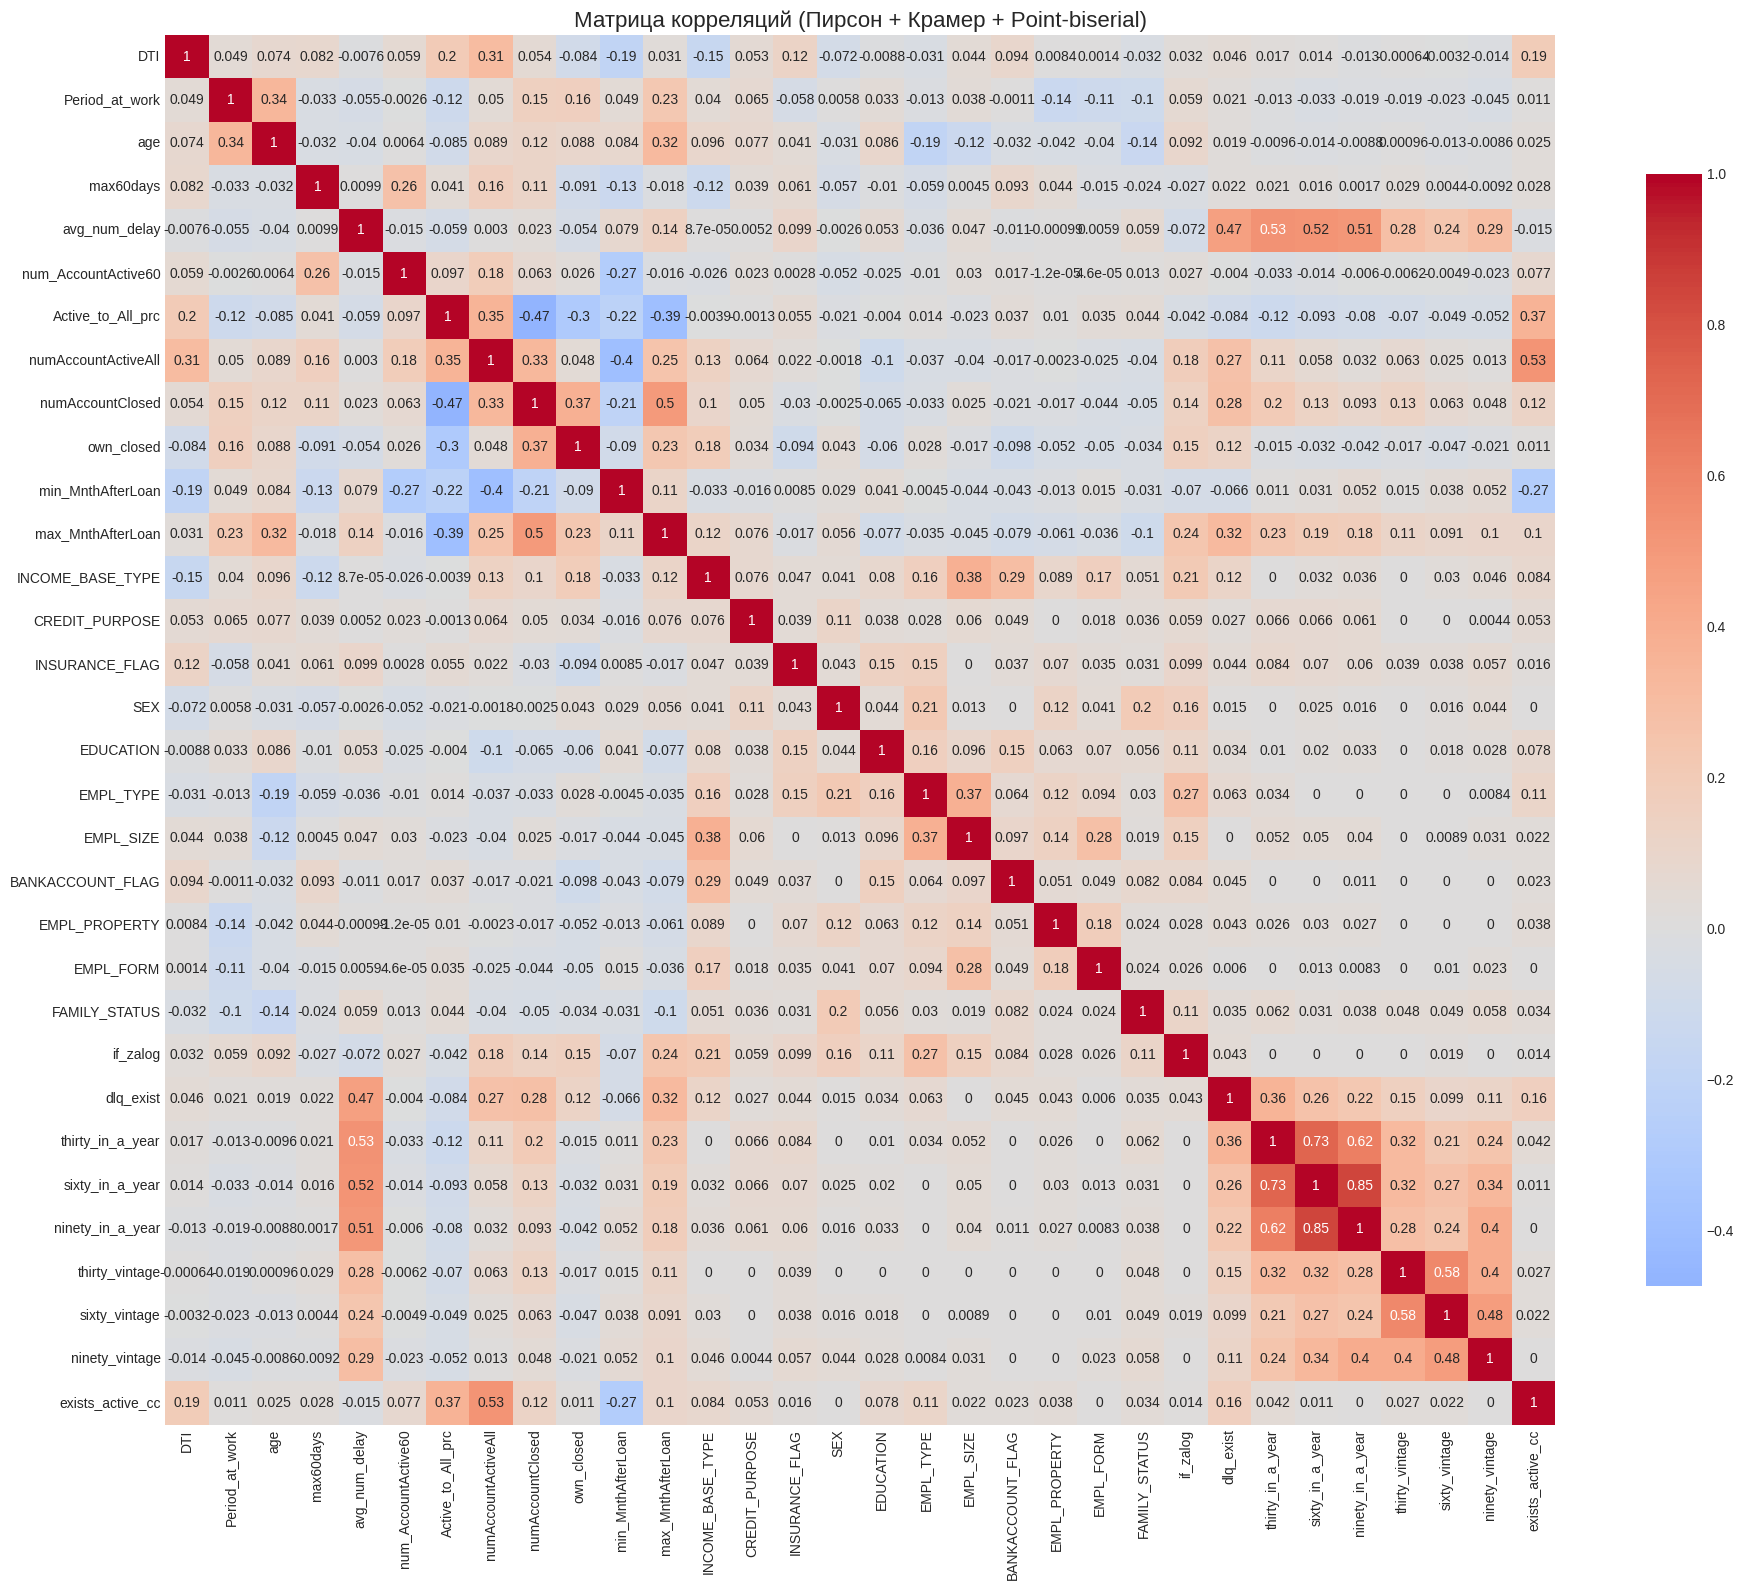


АНАЛИЗ ВЫСОКИХ КОРРЕЛЯЦИЙ (|r| > 0.7)
sixty_in_a_year           <-> ninety_in_a_year          : 0.847
thirty_in_a_year          <-> sixty_in_a_year           : 0.733

Результаты сохранены в 'mixed_correlation_matrix.csv'

СТАТИСТИКА КОРРЕЛЯЦИЙ ПО ТИПАМ:

Средние абсолютные корреляции:
----------------------------------------
Непрерывные-Непрерывные: 0.141
Категориальные-Категориальные: 0.088
Категориальные-Непрерывные: 0.067


In [1131]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, pearsonr
from scipy.stats import pointbiserialr

# Ваши признаки
continuous_features = [
    'DTI',
# 'FULL_AGE_CHILD_NUMBER',
# 'DEPENDANT_NUMBER',
 'Period_at_work',
 'age',
# 'max90days',
 'max60days',
# 'max30days',
# 'max21days',
# 'max14days',
 'avg_num_delay',
# 'num_AccountActive180',
# 'num_AccountActive90',
 'num_AccountActive60',
 'Active_to_All_prc',
 'numAccountActiveAll',
 'numAccountClosed',
# 'sum_of_paym_months',
# 'all_credits',
# 'Active_not_cc',
 'own_closed',
 'min_MnthAfterLoan',
 'max_MnthAfterLoan']

categorical_features = ['INCOME_BASE_TYPE',
 'CREDIT_PURPOSE',
 'INSURANCE_FLAG',
 'SEX',
 'EDUCATION',
 'EMPL_TYPE',
 'EMPL_SIZE',
 'BANKACCOUNT_FLAG',
 'EMPL_PROPERTY',
 'EMPL_FORM',
 'FAMILY_STATUS',
 'if_zalog',
 'dlq_exist',
 'thirty_in_a_year',
'sixty_in_a_year',
 'ninety_in_a_year',
 'thirty_vintage',
 'sixty_vintage',
 'ninety_vintage', 
 'exists_active_cc'
                        ]

# Функция для расчета Cramér's V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Создаем DataFrame для хранения результатов
all_features = continuous_features + categorical_features
correlation_matrix = pd.DataFrame(index=all_features, columns=all_features)

# Заполняем диагональ
for feature in all_features:
    correlation_matrix.loc[feature, feature] = 1.0

print("Расчет корреляций начат...")

# 1. Непрерывные vs Непрерывные (Пирсон)
print("1. Расчет корреляций непрерывных признаков...")
for i, feat1 in enumerate(continuous_features):
    for j, feat2 in enumerate(continuous_features[i+1:], i+1):
        try:
            corr, _ = pearsonr(df_encoded[feat1].dropna(), df_encoded[feat2].dropna())
            correlation_matrix.loc[feat1, feat2] = corr
            correlation_matrix.loc[feat2, feat1] = corr
        except:
            correlation_matrix.loc[feat1, feat2] = np.nan
            correlation_matrix.loc[feat2, feat1] = np.nan

# 2. Категориальные vs Категориальные (Cramér's V)
print("2. Расчет Cramér's V для категориальных признаков...")
for i, feat1 in enumerate(categorical_features):
    for j, feat2 in enumerate(categorical_features[i+1:], i+1):
        try:
            v = cramers_v(df_encoded[feat1].dropna(), df_encoded[feat2].dropna())
            correlation_matrix.loc[feat1, feat2] = v
            correlation_matrix.loc[feat2, feat1] = v
        except:
            correlation_matrix.loc[feat1, feat2] = np.nan
            correlation_matrix.loc[feat2, feat1] = np.nan

# 3. Категориальные vs Непрерывные (Point-biserial)
print("3. Расчет Point-biserial корреляций...")
for cat_feat in categorical_features:
    for cont_feat in continuous_features:
        try:
            # Для point-biserial нужно бинарное или ordinal
            # Если категориальный признак не бинарный, нужно преобразовать
            if df_encoded[cat_feat].nunique() == 2:
                # Бинарный случай
                corr, _ = pointbiserialr(df_encoded[cat_feat].dropna(), df_encoded[cont_feat].dropna())
            else:
                # Для многоклассовых - используем ANOVA альтернативу
                # Здесь простой вариант - преобразуем в числовой
                temp_series = pd.to_numeric(df_encoded[cat_feat], errors='coerce')
                corr, _ = pearsonr(temp_series.dropna(), df_encoded[cont_feat].dropna())
            
            correlation_matrix.loc[cat_feat, cont_feat] = corr
            correlation_matrix.loc[cont_feat, cat_feat] = corr
        except:
            correlation_matrix.loc[cat_feat, cont_feat] = np.nan
            correlation_matrix.loc[cont_feat, cat_feat] = np.nan

# Преобразуем в числовой формат
correlation_matrix = correlation_matrix.astype(float)

print("\n✅ Расчет завершен!")

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            square=True,
            cbar_kws={"shrink": 0.8})
plt.title('Матрица корреляций (Пирсон + Крамер + Point-biserial)', fontsize=16)
plt.tight_layout()
plt.show()

# Анализ высоких корреляций
print("\n" + "="*60)
print("АНАЛИЗ ВЫСОКИХ КОРРЕЛЯЦИЙ (|r| > 0.7)")
print("="*60)

high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = abs(correlation_matrix.iloc[i, j])
        if pd.notna(corr_value) and corr_value > 0.7:
            feat1 = correlation_matrix.columns[i]
            feat2 = correlation_matrix.columns[j]
            high_corr_pairs.append((feat1, feat2, corr_value))

high_corr_pairs.sort(key=lambda x: x[2], reverse=True)

for feat1, feat2, corr in high_corr_pairs[:20]:  # Покажем топ-20
    print(f"{feat1:25} <-> {feat2:25} : {corr:.3f}")

# Сохранение результатов
correlation_matrix.to_csv('mixed_correlation_matrix.csv')
print(f"\nРезультаты сохранены в 'mixed_correlation_matrix.csv'")

# Статистика по типам корреляций
print("\n" + "="*60)
print("СТАТИСТИКА КОРРЕЛЯЦИЙ ПО ТИПАМ:")
print("="*60)

# Считаем средние корреляции
print("\nСредние абсолютные корреляции:")
print("-"*40)

# Непрерывные vs Непрерывные
cont_cont_corrs = []
for i, f1 in enumerate(continuous_features):
    for f2 in continuous_features[i+1:]:
        val = abs(correlation_matrix.loc[f1, f2])
        if pd.notna(val):
            cont_cont_corrs.append(val)
print(f"Непрерывные-Непрерывные: {np.mean(cont_cont_corrs):.3f}")

# Категориальные vs Категориальные
cat_cat_corrs = []
for i, f1 in enumerate(categorical_features):
    for f2 in categorical_features[i+1:]:
        val = abs(correlation_matrix.loc[f1, f2])
        if pd.notna(val):
            cat_cat_corrs.append(val)
print(f"Категориальные-Категориальные: {np.mean(cat_cat_corrs):.3f}")

# Категориальные vs Непрерывные
cat_cont_corrs = []
for cat in categorical_features:
    for cont in continuous_features:
        val = abs(correlation_matrix.loc[cat, cont])
        if pd.notna(val):
            cat_cont_corrs.append(val)
print(f"Категориальные-Непрерывные: {np.mean(cat_cont_corrs):.3f}")

In [1441]:
#Оставим те же категориальные и добавим новый признак exists_active_cc
available_categorical = [
    'INCOME_BASE_TYPE',
 'CREDIT_PURPOSE',
 'INSURANCE_FLAG',
 'SEX',
 'EDUCATION',
 'EMPL_TYPE',
 'EMPL_SIZE',
 'BANKACCOUNT_FLAG',
 'EMPL_PROPERTY',
 'EMPL_FORM',
 'FAMILY_STATUS',
 'if_zalog',
 'dlq_exist',
 'thirty_in_a_year',
# 'sixty_in_a_year',
# 'ninety_in_a_year',
 'thirty_vintage',
# 'sixty_vintage',
# 'ninety_vintage', 
 'exists_active_cc'
                        ]

#Какие количественные признаки останутся
available_numerical = [
    'DTI',
 'FULL_AGE_CHILD_NUMBER',
# 'DEPENDANT_NUMBER',
 'Period_at_work',
 'age',
# 'max90days',
 'max60days',
# 'max30days',
# 'max21days',
# 'max14days',
 'avg_num_delay',
# 'num_AccountActive180',
# 'num_AccountActive90',
# 'num_AccountActive60',
 'Active_to_All_prc',
 'numAccountActiveAll',
 'numAccountClosed',
# 'sum_of_paym_months',
# 'all_credits',
# 'Active_not_cc',
 'own_closed',
 'min_MnthAfterLoan',
 'max_MnthAfterLoan']

In [1405]:
data_copy = data_copy.drop(columns = 'ID')

KeyError: "['ID'] not found in axis"

In [1444]:
data_copy[available_categorical + available_numerical].columns

Index(['INCOME_BASE_TYPE', 'CREDIT_PURPOSE', 'INSURANCE_FLAG', 'SEX',
       'EDUCATION', 'EMPL_TYPE', 'EMPL_SIZE', 'BANKACCOUNT_FLAG',
       'EMPL_PROPERTY', 'EMPL_FORM', 'FAMILY_STATUS', 'if_zalog', 'dlq_exist',
       'thirty_in_a_year', 'thirty_vintage', 'exists_active_cc', 'DTI',
       'FULL_AGE_CHILD_NUMBER', 'Period_at_work', 'age', 'max60days',
       'avg_num_delay', 'Active_to_All_prc', 'numAccountActiveAll',
       'numAccountClosed', 'own_closed', 'min_MnthAfterLoan',
       'max_MnthAfterLoan'],
      dtype='object')

In [1445]:
data_copy[available_categorical + available_numerical].shape

(3733, 28)

## Часть 2 - сегментация

In [1527]:
data_res = pd.concat([pd.get_dummies(data_copy[available_categorical], dtype=float), data_copy[available_numerical]], axis = 1)
               #, prefix=available_categorical)

In [1528]:
data_res.columns

Index(['INSURANCE_FLAG', 'BANKACCOUNT_FLAG', 'if_zalog', 'dlq_exist',
       'thirty_in_a_year', 'thirty_vintage', 'exists_active_cc',
       'INCOME_BASE_TYPE_2НДФЛ',
       'INCOME_BASE_TYPE_Поступление зарплаты на счет',
       'INCOME_BASE_TYPE_Свободная форма с печатью работодателя',
       'INCOME_BASE_TYPE_Форма банка (без печати работодателя)',
       'CREDIT_PURPOSE_Другое', 'CREDIT_PURPOSE_Лечение',
       'CREDIT_PURPOSE_Обучение', 'CREDIT_PURPOSE_Отпуск',
       'CREDIT_PURPOSE_Покупка автомобиля',
       'CREDIT_PURPOSE_Покупка бытовой техники',
       'CREDIT_PURPOSE_Покупка земли', 'CREDIT_PURPOSE_Покупка мебели',
       'CREDIT_PURPOSE_Покупка недвижимости/ строительство',
       'CREDIT_PURPOSE_Ремонт', 'SEX_женский', 'SEX_мужской',
       'EDUCATION_Высшее/Второе высшее/Ученая степень',
       'EDUCATION_Неполное среднее', 'EDUCATION_незаконченное высшее',
       'EDUCATION_среднее', 'EDUCATION_среднее-специальное',
       'EMPL_TYPE_вспомогательный персонал', 'EMPL_T

In [1529]:
data_res.shape

(3733, 67)

In [1424]:
#corr = pd.get_dummies(data_copy[available_categorical], dtype=float).corr(method='spearman').round(2)
#corr.style.background_gradient(cmap='coolwarm')
#.set_precision(2)

#### Удаление выбросов

In [1530]:
%%time
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor

outliers = IsolationForest(n_estimators=20, random_state=0).fit_predict(data_res.values)  # fit 3 trees
outliers = (outliers+1)//2

print('% of outliers with Isolation forest:', 1 - (np.sum(outliers) / data_res.shape[0]))

% of outliers with Isolation forest: 0.1224216447897134
CPU times: user 37.3 ms, sys: 0 ns, total: 37.3 ms
Wall time: 36.5 ms


In [1531]:
df = data_res.loc[np.array(data_res.index)[outliers == 1]]

In [1532]:
df

,INSURANCE_FLAG,BANKACCOUNT_FLAG,if_zalog,dlq_exist,thirty_in_a_year,thirty_vintage,exists_active_cc,INCOME_BASE_TYPE_2НДФЛ,INCOME_BASE_TYPE_Поступление зарплаты на счет,INCOME_BASE_TYPE_Свободная форма с печатью работодателя,INCOME_BASE_TYPE_Форма банка (без печати работодателя),CREDIT_PURPOSE_Другое,CREDIT_PURPOSE_Лечение,CREDIT_PURPOSE_Обучение,CREDIT_PURPOSE_Отпуск,CREDIT_PURPOSE_Покупка автомобиля,CREDIT_PURPOSE_Покупка бытовой техники,CREDIT_PURPOSE_Покупка земли,CREDIT_PURPOSE_Покупка мебели,CREDIT_PURPOSE_Покупка недвижимости/ строительство,CREDIT_PURPOSE_Ремонт,SEX_женский,SEX_мужской,EDUCATION_Высшее/Второе высшее/Ученая степень,EDUCATION_Неполное среднее,EDUCATION_незаконченное высшее,EDUCATION_среднее,EDUCATION_среднее-специальное,EMPL_TYPE_вспомогательный персонал,EMPL_TYPE_другое,EMPL_TYPE_менеджер высшего звена,EMPL_TYPE_менеджер по продажам,EMPL_TYPE_менеджер среднего звена,EMPL_TYPE_рабочий,EMPL_TYPE_специалист,EMPL_TYPE_страховой агент,EMPL_TYPE_торговый представитель,EMPL_SIZE_< 50,EMPL_SIZE_>250,EMPL_PROPERTY_Другое,EMPL_PROPERTY_Информационные технологии,EMPL_PROPERTY_Сельское и лесное хозяйство,EMPL_PROPERTY_Торговля,EMPL_PROPERTY_Юридические услуги,EMPL_FORM_Государственное предприятие,EMPL_FORM_ЗАО,EMPL_FORM_Иная форма,EMPL_FORM_Индивидуальный предприниматель,EMPL_FORM_ОАО,EMPL_FORM_ООО,FAMILY_STATUS_вдовец / вдова,FAMILY_STATUS_гражданский брак,FAMILY_STATUS_женат / замужем,FAMILY_STATUS_разведен / разведена,FAMILY_STATUS_холост / не замужем,DTI,FULL_AGE_CHILD_NUMBER,Period_at_work,age,max60days,avg_num_delay,Active_to_All_prc,numAccountActiveAll,numAccountClosed,own_closed,min_MnthAfterLoan,max_MnthAfterLoan
0,1,0,0,1,0,0,1,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.49,0,109,46,2,0.089109,0.600000,3,2,1,17,43
1,1,0,1,1,0,0,1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.59,0,47,47,0,0.006369,0.555556,5,4,1,18,89
2,1,0,0,0,0,0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.36,0,32,27,0,0.000000,0.000000,0,1,1,32,32
3,1,0,0,0,0,0,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.50,0,6,53,0,0.000000,0.500000,3,3,3,3,28
4,0,0,1,1,0,0,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.47,1,53,26,2,0.023622,0.375000,3,5,0,8,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3739,1,0,0,1,1,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.58,1,111,44,2,0.161290,0.142857,1,6,0,35,92
3740,1,0,0,0,0,0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.36,1,31,32,1,0.000000,0.250000,1,3,0,3,24
3741,1,0,0,0,0,0,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.46,0,107,52,0,0.000000,1.000000,2,0,0,12,13
3742,0,0,0,1,0,0,0,0.0,0.0,1.0,0.0

#### Нормализация и примение метода главных компонент

In [1533]:
from sklearn import preprocessing
scaler = preprocessing.StandardScaler()
# normalize
X = scaler.fit_transform(df)


In [1534]:
from sklearn.decomposition import PCA

# PCA с автоматическим выбором 95% дисперсии
pca = PCA(n_components=3, random_state=42)  # Автоматически выберет сколько нужно для 95% дисперсии
X_pca = pca.fit_transform(X)

print(f"Исходно: {X.shape[1]} признаков")
print(f"После PCA: {X_pca.shape[1]} признаков")
print(f"Сохранено дисперсии: {pca.explained_variance_ratio_.sum():.2%}")

Исходно: 67 признаков
После PCA: 3 признаков
Сохранено дисперсии: 13.75%


#### Кластеризация

In [1535]:
from sklearn.cluster import KMeans #DBSCAN, AgglomerativeClustering, MeanShift, MiniBatchKMeans, OPTICS
from scipy.spatial.distance import cdist

In [1536]:
%%time
# k means determine k
distortions = []
K = range(1,16)
for k in K:
    kmeanModel = KMeans(n_clusters=k, max_iter=500, n_init=20, random_state=42).fit(X)
    distortions.append(sum(np.min(cdist(X, kmeanModel.cluster_centers_, 'euclidean'), axis=1)) / X.shape[0])

    print('{} / {}'.format(k, K[-1]))

1 / 15
2 / 15
3 / 15
4 / 15
5 / 15
6 / 15
7 / 15
8 / 15
9 / 15
10 / 15
11 / 15
12 / 15
13 / 15
14 / 15
15 / 15
CPU times: user 1min 33s, sys: 4min, total: 5min 33s
Wall time: 27.9 s


/tmp/ipykernel_42394/3656104878.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(); plt.show()


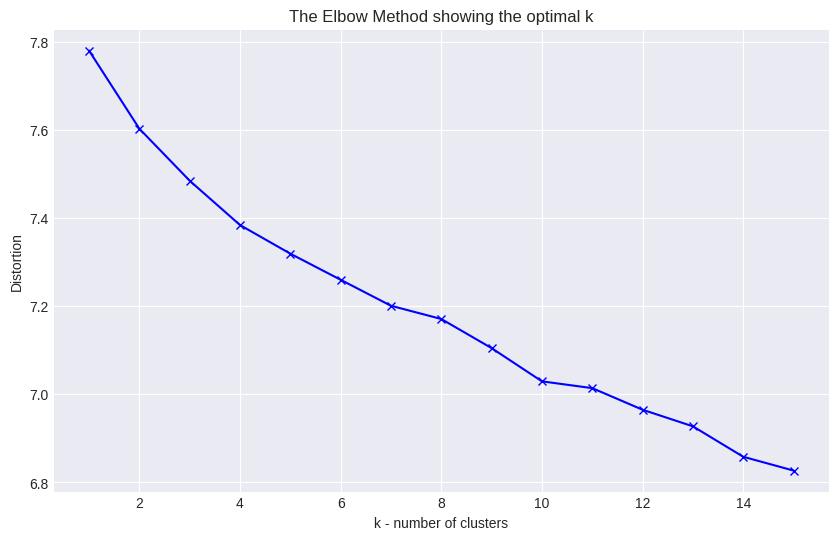

In [1537]:
#определение оптимального к-ва кластеров методом локтя
plt.figure(figsize=(10, 6))
plt.plot(K, distortions, 'bx-')
plt.xlabel('k - number of clusters')
plt.ylabel('Distortion')
plt.title('The Elbow Method showing the optimal k')
plt.legend(); plt.show()

In [1434]:
from sklearn.metrics import davies_bouldin_score
results_db_kmeans = {}
for i in range(2, 16):

    kmeans = KMeans(n_clusters = i, max_iter=500, n_init=20, random_state=42)
    labels = kmeans.fit_predict(X)

    db_index = davies_bouldin_score(X, labels)
    results_db_kmeans.update({i: db_index})


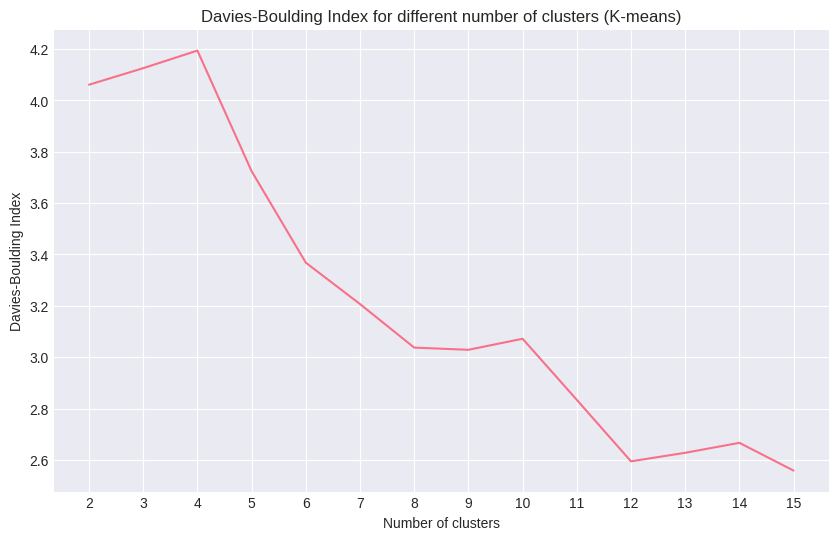

In [1435]:
#plt.style.use('seaborn')
plt.figure(figsize=(10, 6))

plt.plot(list(results_db_kmeans.keys()), list(results_db_kmeans.values()))

plt.xticks(np.arange(2, 16, step = 1))
plt.xlabel('Number of clusters')
plt.ylabel('Davies-Boulding Index')
plt.title('Davies-Boulding Index for different number of clusters (K-means)')
plt.show()

In [1436]:
results_sil_kmeans = {}
for i in range(2, 16):

    kmeans = KMeans(n_clusters = i, max_iter=500, n_init=20, random_state=42)
    labels = kmeans.fit_predict(X)

    sil_score = silhouette_score(X, labels)
    results_sil_kmeans.update({i: sil_score})

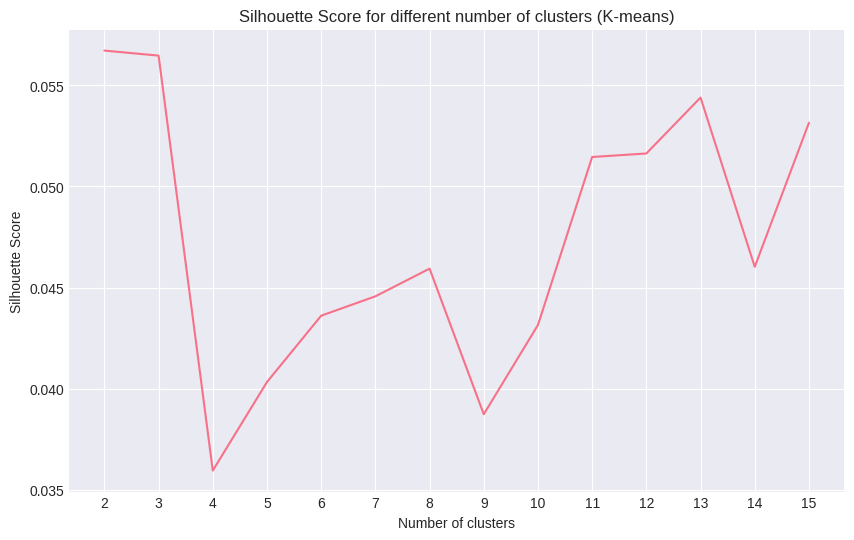

In [1437]:
plt.figure(figsize=(10, 6))

plt.plot(list(results_sil_kmeans.keys()), list(results_sil_kmeans.values()), label = 'Silhouette Score')

plt.xticks(np.arange(2, 16, step = 1))
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for different number of clusters (K-means)')
plt.show()

2. Выполнение кластеризации...
3. Расчет метрик качества...
4. Создание визуализации...


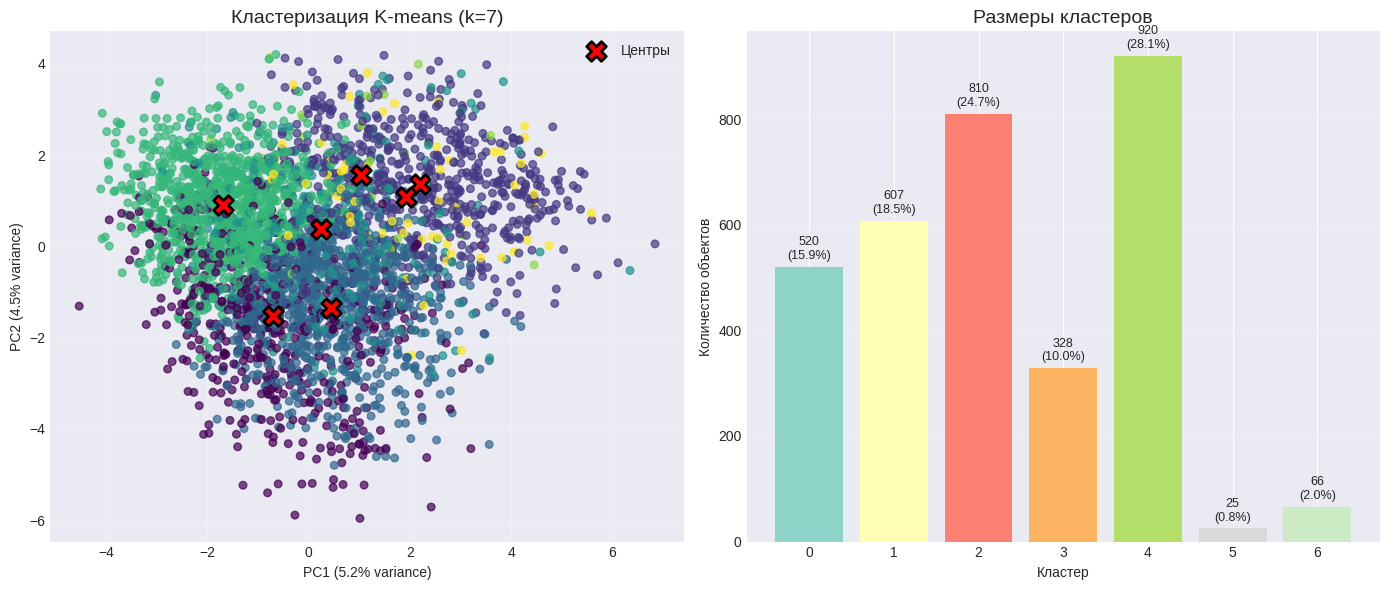


РЕЗУЛЬТАТЫ КЛАСТЕРИЗАЦИИ

📊 ОСНОВНЫЕ МЕТРИКИ:
   Silhouette Score: 0.045 ⚠
   Calinski-Harabasz: 83.3 ✗
   Davies-Bouldin: 3.207 ✗
   Inertia (SSE): 190391

📈 РАЗМЕРЫ КЛАСТЕРОВ:
   Кластер 0: 520 объектов (15.9%)
   Кластер 1: 607 объектов (18.5%)
   Кластер 2: 810 объектов (24.7%)
   Кластер 3: 328 объектов (10.0%)
   Кластер 4: 920 объектов (28.1%)
   Кластер 5: 25 объектов (0.8%)
   Кластер 6: 66 объектов (2.0%)


In [1461]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

def simple_kmeans_clustering(X_scaled, n_clusters=5, random_state=42):
    """
    Простая K-means кластеризация с визуализацией и основными метриками.
    
    Parameters:
    -----------
    df : pandas DataFrame
        Исходные данные
    features : list
        Список признаков для кластеризации
    n_clusters : int, default=5
        Количество кластеров
    random_state : int, default=42
        Seed для воспроизводимости
    
    Returns:
    --------
    dict : Результаты кластеризации
    """
    
    # 2. Кластеризация
    print("2. Выполнение кластеризации...")
    
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=20, max_iter = 500)
    labels = kmeans.fit_predict(X_scaled)
    centers = kmeans.cluster_centers_
    
    # 3. Расчет метрик
    print("3. Расчет метрик качества...")
    
    silhouette = silhouette_score(X_scaled, labels)
    calinski = calinski_harabasz_score(X_scaled, labels)
    davies = davies_bouldin_score(X_scaled, labels)
    inertia = kmeans.inertia_
    
    # Размеры кластеров
    cluster_sizes = pd.Series(labels).value_counts().sort_index()
    max_size_pct = cluster_sizes.max() / len(X) * 100
    
    # Проверка условий задания
    violations = []
    if len(cluster_sizes) < 5:
        violations.append(f"Мало кластеров: {len(cluster_sizes)}")
    if max_size_pct > 50:
        violations.append(f"Кластер >50%: {max_size_pct:.1f}%")
    
    is_valid = len(violations) == 0
    
    # 4. Визуализация через PCA
    print("4. Создание визуализации...")
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # PCA для визуализации
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    # Визуализация кластеров
    scatter = ax1.scatter(X_pca[:, 0], X_pca[:, 1], 
                         c=labels, cmap='viridis', alpha=0.7, s=30)
    ax1.set_title(f'Кластеризация K-means (k={n_clusters})', fontsize=14)
    ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
    ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
    ax1.grid(True, alpha=0.3)
    
    # Добавляем центры кластеров в PCA пространстве
    centers_pca = pca.transform(centers)
    ax1.scatter(centers_pca[:, 0], centers_pca[:, 1], 
               marker='X', s=200, c='red', edgecolors='black', linewidth=2, label='Центры')
    ax1.legend()
    
    # 5. Визуализация метрик и размеров кластеров
    # Размеры кластеров
    colors = plt.cm.Set3(np.arange(n_clusters) / n_clusters)
    bars = ax2.bar(range(n_clusters), cluster_sizes.values, color=colors)
    ax2.set_title('Размеры кластеров', fontsize=14)
    ax2.set_xlabel('Кластер')
    ax2.set_ylabel('Количество объектов')
    ax2.set_xticks(range(n_clusters))
    
    # Добавляем проценты на столбцы
    for bar, size in zip(bars, cluster_sizes.values):
        height = bar.get_height()
        percentage = size / len(X) * 100
        ax2.text(bar.get_x() + bar.get_width()/2., height + max(cluster_sizes.values)*0.01,
                f'{size}\n({percentage:.1f}%)', ha='center', va='bottom', fontsize=9)
    
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # 6. Вывод метрик
    print("\n" + "="*60)
    print("РЕЗУЛЬТАТЫ КЛАСТЕРИЗАЦИИ")
    print("="*60)
    
    print(f"\n📊 ОСНОВНЫЕ МЕТРИКИ:")
    print(f"   Silhouette Score: {silhouette:.3f} {'✓' if silhouette > 0.5 else '⚠' if silhouette > 0 else '✗'}")
    print(f"   Calinski-Harabasz: {calinski:.1f} {'✓' if calinski > 200 else '⚠' if calinski > 100 else '✗'}")
    print(f"   Davies-Bouldin: {davies:.3f} {'✓' if davies < 0.5 else '⚠' if davies < 1 else '✗'}")
    print(f"   Inertia (SSE): {inertia:.0f}")
    
    print(f"\n📈 РАЗМЕРЫ КЛАСТЕРОВ:")
    for cluster, size in cluster_sizes.items():
        percentage = size / len(X) * 100
        print(f"   Кластер {cluster}: {size} объектов ({percentage:.1f}%)")
    
    
   
    # 8. Возвращаем результаты
    results = {
        'labels': labels,
        'centers': centers,
        'scaler': scaler,
        'X_scaled': X_scaled
    }
    
    return results


# Пример использования
results = simple_kmeans_clustering(X, n_clusters=7)
    
# Запустить пример
# results = example_usage()

In [1462]:
df['res'] = labels

In [1480]:
len(labels)

3276

In [1482]:
df['res'].isna().sum()

0

In [1478]:
df.groupby('res')[df.columns].mean().T.to_excel('mean_data.xlsx')

In [1455]:
df.to_excel('K_means.xlsx')

#### RFM сегментация

In [1488]:
def create_corrected_5_segment_rfm(df, 
                                  recency_col='min_MnthAfterLoan',
                                  frequency_col='all_credits',
                                  monetary_col='sum_of_paym_months',
                                  n_quantiles=5):
    """
    RFM анализ с логикой, соответствующей таблице с описанием критериев.
    Логика основана на четких качественных описаниях для каждой оценки.
    """
    
    df_rfm = df.copy()
    
    
    # 1. Рассчитываем оценки R, F, M
    # Recency: чем МЕНЬШЕ значение - тем ВЫШЕ оценка (инвертируем)
    df_rfm['R_raw'] = df_rfm[recency_col]
    df_rfm['R_rank'] = df_rfm[recency_col].rank(method='first', ascending=True)
    df_rfm['R_score'] = pd.qcut(df_rfm['R_rank'], n_quantiles, 
                               labels=range(n_quantiles, 0, -1))
    df_rfm['R_score'] = df_rfm['R_score'].astype(int)
    
    # Frequency: чем БОЛЬШЕ значение - тем ВЫШЕ оценка
    df_rfm['F_raw'] = df_rfm[frequency_col]
    df_rfm['F_score'] = pd.qcut(df_rfm[frequency_col].rank(method='first'), 
                               n_quantiles, labels=range(1, n_quantiles+1))
    df_rfm['F_score'] = df_rfm['F_score'].astype(int)
    
    # Monetary: чем БОЛЬШЕ значение - тем ВЫШЕ оценка
    df_rfm['M_raw'] = df_rfm[monetary_col]
    df_rfm['M_score'] = pd.qcut(df_rfm[monetary_col].rank(method='first'), 
                               n_quantiles, labels=range(1, n_quantiles+1))
    df_rfm['M_score'] = df_rfm['M_score'].astype(int)
    
    # 2. СЕГМЕНТАЦИЯ ПО ЛОГИКЕ КАРТИНКИ (5 ГРУПП)
    def assign_final_5_segments(row):
        r, f, m = row['R_score'], row['F_score'], row['M_score']
        
        # 1. VIP/ЛУЧШИЕ КЛИЕНТЫ (все показатели высокие)
        if r >= 4 and f >= 4 and m >= 4:
            return '1. VIP/Лучшие клиенты'
        
        # 2. ЛОЯЛЬНЫЕ КЛИЕНТЫ (хорошие по активности, могут быть средние по деньгам)
        elif (r >= 3 and f >= 3) or (f >= 4 and r >= 2):
            # Разделяем на подгруппы для детализации, но потом объединим
            if m >= 3:
                return '2_Лояльные_ценные'
            else:
                return '2_Лояльные_активные'
        
        # 3. ВЫСОКОЦЕННЫЕ КЛИЕНТЫ (главное - высокий Monetary)
        elif m >= 4:
            # Разделяем на активных и спящих
            if r >= 3:
                return '3_Высокоценные_активные'
            else:
                return '3_Высокоценные_спящие'
        
        # 4. ПОТЕНЦИАЛЬНЫЕ/НОВЫЕ КЛИЕНТЫ (хороший Recency, но еще не раскрылись)
        elif r >= 4:
            return '4_Потенциальные'
        
        # 5. РИСК ОТТОКА (плохой Recency или низкая ценность)
        else:
            # Разделяем по типу риска
            if m >= 3:
                return '5_Спящие_ценные'
            elif f >= 3:
                return '5_Неактивные_частые'
            else:
                return '5_Низкоценные'
    
    df_rfm['segment_detail'] = df_rfm.apply(assign_final_5_segments, axis=1)
    
    # 3. ОБЪЕДИНЕНИЕ В 5 ФИНАЛЬНЫХ СЕГМЕНТОВ
    segment_mapping = {
        # Группа 1: VIP
        '1. VIP/Лучшие клиенты': '1. VIP/Лучшие клиенты',
        
        # Группа 2: Лояльные (объединяем все подгруппы)
        '2_Лояльные_ценные': '2. Лояльные клиенты',
        '2_Лояльные_активные': '2. Лояльные клиенты',
        
        # Группа 3: Высокоценные (объединяем все подгруппы)
        '3_Высокоценные_активные': '3. Высокоценные клиенты',
        '3_Высокоценные_спящие': '3. Высокоценные клиенты',
        
        # Группа 4: Потенциальные
        '4_Потенциальные': '4. Потенциальные клиенты',
        
        # Группа 5: Риск оттока (объединяем все подгруппы)
        '5_Спящие_ценные': '5. Риск оттока',
        '5_Неактивные_частые': '5. Риск оттока',
        '5_Низкоценные': '5. Риск оттока'
    }
    
    df_rfm['segment'] = df_rfm['segment_detail'].map(segment_mapping)
    
    # 4. СТАТИСТИКА ПО ФИНАЛЬНЫМ 5 СЕГМЕНТАМ (С МОДОЙ И МЕДИАНОЙ)
    print(f"\n{'='*80}")
    print("📈 СТАТИСТИКА ПО 5 ФИНАЛЬНЫМ СЕГМЕНТАМ (МОДА И МЕДИАНА)")
    print(f"{'='*80}")
    
    # Функция для расчета моды (возвращает первую моду)
    def calculate_mode(series):
        mode_vals = series.mode()
        return mode_vals.iloc[0] if len(mode_vals) > 0 else None
    
    # Группируем и рассчитываем статистики
    segment_groups = df_rfm.groupby('segment')
    
    total_clients = len(df_rfm)
    total_monetary = df_rfm[monetary_col].sum()
    
    print(f"\n{'Сегмент':<30} {'Клиентов':<10} {'Доля,%':<8} {'Доход,%':<10} {'R(мод)':<7} {'F(мод)':<7} {'M(мод)':<7} {'Recency(мед)':<12} {'Frequency(мед)':<15} {'Monetary(мед)':<15}")
    print("-"*130)
    
    # Сортируем сегменты по номеру (1., 2., 3., 4., 5.)
    sorted_segments = sorted(df_rfm['segment'].unique())
    
    for segment in sorted_segments:
        segment_data = df_rfm[df_rfm['segment'] == segment]
        
        # Базовые метрики
        count = len(segment_data)
        pct = count / total_clients * 100
        income_sum = segment_data[monetary_col].sum()
        income_pct = (income_sum / total_monetary * 100) if total_monetary > 0 else 0
        
        # МОДЫ для RFM scores
        r_mode = calculate_mode(segment_data['R_score'])
        f_mode = calculate_mode(segment_data['F_score'])
        m_mode = calculate_mode(segment_data['M_score'])
        
        # МЕДИАНЫ для исходных значений
        recency_median = segment_data[recency_col].median()
        frequency_median = segment_data[frequency_col].median()
        monetary_median = segment_data[monetary_col].median()
        
        # Также считаем медианы для scores (на всякий случай)
        r_median = segment_data['R_score'].median()
        f_median = segment_data['F_score'].median()
        m_median = segment_data['M_score'].median()
        
        print(f"{segment:<30} {count:<10} {pct:<7.1f} {income_pct:<9.1f} {r_mode if r_mode is not None else '-':<7} {f_mode if f_mode is not None else '-':<7} {m_mode if m_mode is not None else '-':<7} {recency_median:<12.1f} {frequency_median:<15.1f} {monetary_median:<15.1f}")
    
    
    # 6. ДЕТАЛИЗИРОВАННАЯ СТАТИСТИКА ПО ПОДГРУППАМ (для отладки)
    print(f"\n{'='*80}")
    print("🔍 ДЕТАЛИЗИРОВАННАЯ СТАТИСТИКА ПО ПОДГРУППАМ")
    print(f"{'='*80}")
    
    # Создаем DataFrame с модами и медианами для подгрупп
    subgroup_stats = []
    
    for subgroup in df_rfm['segment_detail'].unique():
        subgroup_data = df_rfm[df_rfm['segment_detail'] == subgroup]
        count = len(subgroup_data)
        
        if count > 0:
            # Моды
            r_mode = calculate_mode(subgroup_data['R_score'])
            f_mode = calculate_mode(subgroup_data['F_score'])
            m_mode = calculate_mode(subgroup_data['M_score'])
            
            # Медианы исходных значений
            recency_median = subgroup_data[recency_col].median()
            frequency_median = subgroup_data[frequency_col].median()
            monetary_median = subgroup_data[monetary_col].median()
            
            # Доход
            income_sum = subgroup_data[monetary_col].sum()
            income_pct = (income_sum / total_monetary * 100) if total_monetary > 0 else 0
            
            subgroup_stats.append({
                'Подгруппа': subgroup,
                'Клиентов': count,
                'R(мода)': r_mode,
                'F(мода)': f_mode,
                'M(мода)': m_mode,
                'Recency(мед)': recency_median,
                'Frequency(мед)': frequency_median,
                'Monetary(мед)': monetary_median,
                'Доход': income_sum,
                'Доход,%': income_pct
            })
    
    # Создаем DataFrame и выводим
    if subgroup_stats:
        subgroup_df = pd.DataFrame(subgroup_stats)
        subgroup_df = subgroup_df.sort_values('Подгруппа')
        
        print(f"\n{'Подгруппа':<25} {'Клиентов':<10} {'R(мод)':<7} {'F(мод)':<7} {'M(мод)':<7} {'Recency(мед)':<12} {'Frequency(мед)':<15} {'Monetary(мед)':<15} {'Доход,%':<10}")
        print("-"*120)
        
        for _, row in subgroup_df.iterrows():
            print(f"{row['Подгруппа']:<25} {row['Клиентов']:<10} {row['R(мода)'] if pd.notna(row['R(мода)']) else '-':<7} {row['F(мода)'] if pd.notna(row['F(мода)']) else '-':<7} {row['M(мода)'] if pd.notna(row['M(мода)']) else '-':<7} {row['Recency(мед)']:<12.1f} {row['Frequency(мед)']:<15.1f} {row['Monetary(мед)']:<15.1f} {row['Доход,%']:<9.1f}")
    
    # 7. ОБЩИЙ АНАЛИЗ РАСПРЕДЕЛЕНИЯ RFM SCORES
    print(f"\n{'='*80}")
    print("📊 РАСПРЕДЕЛЕНИЕ RFM SCORES ПО ВСЕЙ БАЗЕ")
    print(f"{'='*80}")
    
    # Моды для всей базы
    r_mode_all = calculate_mode(df_rfm['R_score'])
    f_mode_all = calculate_mode(df_rfm['F_score'])
    m_mode_all = calculate_mode(df_rfm['M_score'])
    
    # Медианы для всей базы
    r_median_all = df_rfm['R_score'].median()
    f_median_all = df_rfm['F_score'].median()
    m_median_all = df_rfm['M_score'].median()
    
    # Средние для всей базы
    r_mean_all = df_rfm['R_score'].mean()
    f_mean_all = df_rfm['F_score'].mean()
    m_mean_all = df_rfm['M_score'].mean()
    
    print(f"\nПо всей базе клиентов ({total_clients} чел):")
    print(f"  📅 Recency Score:   Мода={r_mode_all}, Медиана={r_median_all:.1f}, Среднее={r_mean_all:.2f}")
    print(f"  🔄 Frequency Score: Мода={f_mode_all}, Медиана={f_median_all:.1f}, Среднее={f_mean_all:.2f}")
    print(f"  💰 Monetary Score:  Мода={m_mode_all}, Медиана={m_median_all:.1f}, Среднее={m_mean_all:.2f}")
    
    # 8. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
    # Добавляем RFM комбинацию
    df_rfm['RFM_combination'] = df_rfm['R_score'].astype(str) + '-' + \
                               df_rfm['F_score'].astype(str) + '-' + \
                               df_rfm['M_score'].astype(str)
    
    # Добавляем общий RFM score
    df_rfm['RFM_score'] = df_rfm['R_score'] + df_rfm['F_score'] + df_rfm['M_score']
    
    # Рассчитываем общую моду и медиану RFM score
    rfm_mode = calculate_mode(df_rfm['RFM_score'])
    rfm_median = df_rfm['RFM_score'].median()
    rfm_mean = df_rfm['RFM_score'].mean()
    
    print(f"\n📈 Общий RFM Score (сумма R+F+M):")
    print(f"   Мода: {rfm_mode if rfm_mode is not None else 'Нет'}")
    print(f"   Медиана: {rfm_median:.1f}")
    print(f"   Среднее: {rfm_mean:.2f}")
    print(f"   Диапазон: {df_rfm['RFM_score'].min()} - {df_rfm['RFM_score'].max()}")
    
    print(f"\n✅ Анализ завершен. Всего проанализировано {total_clients} клиентов.")
    
    return df_rfm, None  # Возвращаем только df_rfm, так как статистика выведена в консоль

# Вызываем функцию
result_df, _ = create_corrected_5_segment_rfm(data_copy)


📈 СТАТИСТИКА ПО 5 ФИНАЛЬНЫМ СЕГМЕНТАМ (МОДА И МЕДИАНА)

Сегмент                        Клиентов   Доля,%   Доход,%    R(мод)  F(мод)  M(мод)  Recency(мед) Frequency(мед)  Monetary(мед)  
----------------------------------------------------------------------------------------------------------------------------------
1. VIP/Лучшие клиенты          576        15.4    29.9      5       5       5       3.0          10.0            142.0          
2. Лояльные клиенты            1256       33.6    39.9      3       4       3       8.0          7.0             77.0           
3. Высокоценные клиенты        331        8.9     14.2      1       3       4       24.0         5.0             114.0          
4. Потенциальные клиенты       368        9.9     2.7       4       2       1       3.0          3.0             20.0           
5. Риск оттока                 1202       32.2    13.2      1       1       1       18.0         2.0             31.0           

🔍 ДЕТАЛИЗИРОВАННАЯ СТАТИСТИКА ПО ПО

,RFM_combination,RFM_score
0,1-1-1,166
1,1-1-2,100
2,1-1-3,41
3,1-1-4,11
4,1-1-5,1
...,...,...
101,5-4-5,25
102,5-5-2,2
103,5-5-3,28
104,5-5-4,73


/tmp/ipykernel_42394/282702045.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right', fontsize=11)


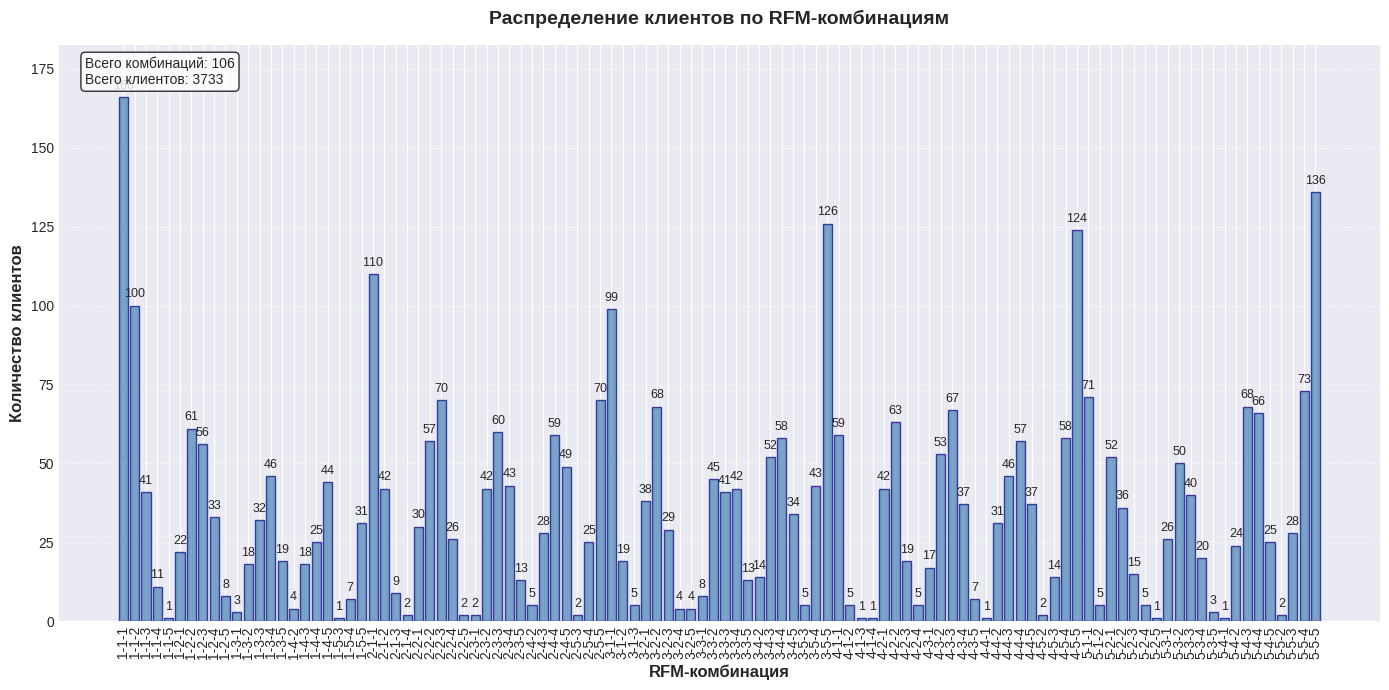

СТАТИСТИКА РАСПРЕДЕЛЕНИЯ
Всего комбинаций: 106
Всего клиентов: 3733
Среднее на комбинацию: 35.2
Медиана: 29.5
Максимум: 166 (1-1-1)
Минимум: 1 (1-1-5)

Топ-5 комбинаций:
  1. 1-1-1: 166 клиентов (4.4%)
  2. 5-5-5: 136 клиентов (3.6%)
  3. 3-5-5: 126 клиентов (3.4%)
  4. 4-5-5: 124 клиентов (3.3%)
  5. 2-1-1: 110 клиентов (2.9%)


In [1505]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np



# Создаем DataFrame
rfm_counts =result_df.groupby(['RFM_combination'])['RFM_score'].count().reset_index()
rfm_counts.columns = ['RFM_combination', 'count']
# Если у вас уже есть DataFrame result_df, используйте его:
# rfm_counts = result_df.groupby(['RFM_combination'])['RFM_score'].count().reset_index()
# rfm_counts.columns = ['RFM_combination', 'count']
# rfm_counts = rfm_counts.sort_values('RFM_combination')

# Сортируем по RFM_combination для правильного порядка
rfm_counts = rfm_counts.sort_values('RFM_combination')

# Создаем график
plt.figure(figsize=(14, 7))

# Простой bar plot
bars = plt.bar(range(len(rfm_counts)), rfm_counts['count'], 
               color='steelblue', edgecolor='navy', alpha=0.7, width=0.8)

# Настройки осей
plt.xlabel('RFM-комбинация', fontsize=12, fontweight='bold')
plt.ylabel('Количество клиентов', fontsize=12, fontweight='bold')
plt.title('Распределение клиентов по RFM-комбинациям', fontsize=14, fontweight='bold', pad=15)

# Подписи по оси X (все комбинации)
plt.xticks(range(len(rfm_counts)), rfm_counts['RFM_combination'], rotation=90, fontsize=10)

# Сетка
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Автоматическая настройка пределов Y
max_count = rfm_counts['count'].max()
plt.ylim(0, max_count * 1.1)

# Добавляем значения на вершинах столбцов
for i, (bar, count) in enumerate(zip(bars, rfm_counts['count'])):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + max_count*0.01,
             f'{int(count)}', ha='center', va='bottom', fontsize=9)

# Статистические линии
mean_count = rfm_counts['count'].mean()
median_count = rfm_counts['count'].median()

# Легенда
plt.legend(loc='upper right', fontsize=11)

# Информация в углу
info_text = f'Всего комбинаций: {len(rfm_counts)}\nВсего клиентов: {rfm_counts["count"].sum()}'
plt.text(0.02, 0.98, info_text, transform=plt.gca().transAxes, 
         fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Выводим статистику
print("="*50)
print("СТАТИСТИКА РАСПРЕДЕЛЕНИЯ")
print("="*50)
print(f"Всего комбинаций: {len(rfm_counts)}")
print(f"Всего клиентов: {rfm_counts['count'].sum()}")
print(f"Среднее на комбинацию: {mean_count:.1f}")
print(f"Медиана: {median_count:.1f}")
print(f"Максимум: {rfm_counts['count'].max()} ({rfm_counts.loc[rfm_counts['count'].idxmax(), 'RFM_combination']})")
print(f"Минимум: {rfm_counts['count'].min()} ({rfm_counts.loc[rfm_counts['count'].idxmin(), 'RFM_combination']})")

# Топ-5 комбинаций
print(f"\nТоп-5 комбинаций:")
top_5 = rfm_counts.nlargest(5, 'count')
for i, (_, row) in enumerate(top_5.iterrows(), 1):
    pct = row['count'] / rfm_counts['count'].sum() * 100
    print(f"  {i}. {row['RFM_combination']}: {row['count']} клиентов ({pct:.1f}%)")

In [1515]:
df['rfm'] = result_df.loc[df.index, 'segment']

In [1524]:
df.groupby(['rfm'])[df.columns[:-2]].mean().T.to_excel('rfm_res.xlsx')

In [1521]:
df

,INSURANCE_FLAG,BANKACCOUNT_FLAG,if_zalog,dlq_exist,thirty_in_a_year,thirty_vintage,exists_active_cc,INCOME_BASE_TYPE_2НДФЛ,INCOME_BASE_TYPE_Поступление зарплаты на счет,INCOME_BASE_TYPE_Свободная форма с печатью работодателя,INCOME_BASE_TYPE_Форма банка (без печати работодателя),CREDIT_PURPOSE_Другое,CREDIT_PURPOSE_Лечение,CREDIT_PURPOSE_Обучение,CREDIT_PURPOSE_Отпуск,CREDIT_PURPOSE_Покупка автомобиля,CREDIT_PURPOSE_Покупка бытовой техники,CREDIT_PURPOSE_Покупка земли,CREDIT_PURPOSE_Покупка мебели,CREDIT_PURPOSE_Покупка недвижимости/ строительство,CREDIT_PURPOSE_Ремонт,SEX_женский,SEX_мужской,EDUCATION_Высшее/Второе высшее/Ученая степень,EDUCATION_Неполное среднее,EDUCATION_незаконченное высшее,EDUCATION_среднее,EDUCATION_среднее-специальное,EMPL_TYPE_вспомогательный персонал,EMPL_TYPE_другое,EMPL_TYPE_менеджер высшего звена,EMPL_TYPE_менеджер по продажам,EMPL_TYPE_менеджер среднего звена,EMPL_TYPE_рабочий,EMPL_TYPE_специалист,EMPL_TYPE_страховой агент,EMPL_TYPE_торговый представитель,EMPL_SIZE_< 50,EMPL_SIZE_>250,EMPL_PROPERTY_Другое,EMPL_PROPERTY_Информационные технологии,EMPL_PROPERTY_Сельское и лесное хозяйство,EMPL_PROPERTY_Торговля,EMPL_PROPERTY_Юридические услуги,EMPL_FORM_Государственное предприятие,EMPL_FORM_ЗАО,EMPL_FORM_Иная форма,EMPL_FORM_Индивидуальный предприниматель,EMPL_FORM_ОАО,EMPL_FORM_ООО,FAMILY_STATUS_вдовец / вдова,FAMILY_STATUS_гражданский брак,FAMILY_STATUS_женат / замужем,FAMILY_STATUS_разведен / разведена,FAMILY_STATUS_холост / не замужем,DTI,FULL_AGE_CHILD_NUMBER,Period_at_work,age,max60days,avg_num_delay,Active_to_All_prc,numAccountActiveAll,numAccountClosed,own_closed,min_MnthAfterLoan,max_MnthAfterLoan,res,rfm
0,1,0,0,1,0,0,1,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.49,0,109,46,2,0.089109,0.600000,3,2,1,17,43,5,3. Высокоценные клиенты
1,1,0,1,1,0,0,1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.59,0,47,47,0,0.006369,0.555556,5,4,1,18,89,5,2. Лояльные клиенты
2,1,0,0,0,0,0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.36,0,32,27,0,0.000000,0.000000,0,1,1,32,32,5,5. Риск оттока
3,1,0,0,0,0,0,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.50,0,6,53,0,0.000000,0.500000,3,3,3,3,28,2,2. Лояльные клиенты
4,0,0,1,1,0,0,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.47,1,53,26,2,0.023622,0.375000,3,5,0,8,50,4,2. Лояльные клиенты
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3739,1,0,0,1,1,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.58,1,111,44,2,0.161290,0.142857,1,6,0,35,92,4,5. Риск оттока
3740,1,0,0,0,0,0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.36,1,31,32,1,0.000000,0.250000,1,3,0,3,24,6,2. Лояльные клиенты
3741,1,0,0,0,0,0,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,

In [1518]:
df

,INSURANCE_FLAG,BANKACCOUNT_FLAG,if_zalog,dlq_exist,thirty_in_a_year,thirty_vintage,exists_active_cc,INCOME_BASE_TYPE_2НДФЛ,INCOME_BASE_TYPE_Поступление зарплаты на счет,INCOME_BASE_TYPE_Свободная форма с печатью работодателя,INCOME_BASE_TYPE_Форма банка (без печати работодателя),CREDIT_PURPOSE_Другое,CREDIT_PURPOSE_Лечение,CREDIT_PURPOSE_Обучение,CREDIT_PURPOSE_Отпуск,CREDIT_PURPOSE_Покупка автомобиля,CREDIT_PURPOSE_Покупка бытовой техники,CREDIT_PURPOSE_Покупка земли,CREDIT_PURPOSE_Покупка мебели,CREDIT_PURPOSE_Покупка недвижимости/ строительство,CREDIT_PURPOSE_Ремонт,SEX_женский,SEX_мужской,EDUCATION_Высшее/Второе высшее/Ученая степень,EDUCATION_Неполное среднее,EDUCATION_незаконченное высшее,EDUCATION_среднее,EDUCATION_среднее-специальное,EMPL_TYPE_вспомогательный персонал,EMPL_TYPE_другое,EMPL_TYPE_менеджер высшего звена,EMPL_TYPE_менеджер по продажам,EMPL_TYPE_менеджер среднего звена,EMPL_TYPE_рабочий,EMPL_TYPE_специалист,EMPL_TYPE_страховой агент,EMPL_TYPE_торговый представитель,EMPL_SIZE_< 50,EMPL_SIZE_>250,EMPL_PROPERTY_Другое,EMPL_PROPERTY_Информационные технологии,EMPL_PROPERTY_Сельское и лесное хозяйство,EMPL_PROPERTY_Торговля,EMPL_PROPERTY_Юридические услуги,EMPL_FORM_Государственное предприятие,EMPL_FORM_ЗАО,EMPL_FORM_Иная форма,EMPL_FORM_Индивидуальный предприниматель,EMPL_FORM_ОАО,EMPL_FORM_ООО,FAMILY_STATUS_вдовец / вдова,FAMILY_STATUS_гражданский брак,FAMILY_STATUS_женат / замужем,FAMILY_STATUS_разведен / разведена,FAMILY_STATUS_холост / не замужем,DTI,FULL_AGE_CHILD_NUMBER,Period_at_work,age,max60days,avg_num_delay,Active_to_All_prc,numAccountActiveAll,numAccountClosed,own_closed,min_MnthAfterLoan,max_MnthAfterLoan,res,rfm
0,1,0,0,1,0,0,1,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.49,0,109,46,2,0.089109,0.600000,3,2,1,17,43,5,3. Высокоценные клиенты
1,1,0,1,1,0,0,1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.59,0,47,47,0,0.006369,0.555556,5,4,1,18,89,5,2. Лояльные клиенты
2,1,0,0,0,0,0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.36,0,32,27,0,0.000000,0.000000,0,1,1,32,32,5,5. Риск оттока
3,1,0,0,0,0,0,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.50,0,6,53,0,0.000000,0.500000,3,3,3,3,28,2,2. Лояльные клиенты
4,0,0,1,1,0,0,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.47,1,53,26,2,0.023622,0.375000,3,5,0,8,50,4,2. Лояльные клиенты
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3739,1,0,0,1,1,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.58,1,111,44,2,0.161290,0.142857,1,6,0,35,92,4,5. Риск оттока
3740,1,0,0,0,0,0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.36,1,31,32,1,0.000000,0.250000,1,3,0,3,24,6,2. Лояльные клиенты
3741,1,0,0,0,0,0,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,